In [713]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

summary_path = Path("/Users/bigrorz/UnityProjects/MultipleStyleRendering/ProfilingLogs/summary.csv")

df = pd.read_csv(summary_path)

# clean strings
df["render_mode"] = df["render_mode"].astype(str).str.strip()
df["test_name"] = df["test_name"].astype(str).str.strip()

# ensure numerics
numeric_cols = [
    "value", "N", "K", "styles_per_object",
    "mean_cpu_ms", "median_cpu_ms", "p95_cpu_ms", "p99_cpu_ms", "max_cpu_ms", "std_cpu_ms",
    "mean_gpu_ms", "median_gpu_ms", "p95_gpu_ms", "p99_gpu_ms", "max_gpu_ms", "std_gpu_ms"
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

METHODS = {"CPU", "GPU", "Fullscreen", "Tiling"}

def parse_ablation_fields(test_name: str):
    tokens = str(test_name).split("_")

    result = {
        "base_test_name": None,
        "merge": None,         # True / False / None
        "occlusion": None,     # True / False / None
        "style_variant": None, # optional helper
        "shader_variant": "Default",
    }

    # heavy
    if "Heavy" in tokens:
        result["shader_variant"] = "Heavy"
        tokens.remove("Heavy")

    # style variant helper
    if "RandomSingleStyle" in tokens:
        result["style_variant"] = "RandomSingleStyle"
        tokens.remove("RandomSingleStyle")
    elif "SameStyle" in tokens:
        result["style_variant"] = "SameStyle"
        tokens.remove("SameStyle")

    # ablations
    if "NoMerge" in tokens:
        result["merge"] = False
        tokens.remove("NoMerge")
    elif "Merge" in tokens:
        result["merge"] = True
        tokens.remove("Merge")

    if "NoOcclusion" in tokens:
        result["occlusion"] = False
        tokens.remove("NoOcclusion")
    elif "Occlusion" in tokens:
        result["occlusion"] = True
        tokens.remove("Occlusion")

    result["base_test_name"] = "_".join(tokens)
    return result


parsed = df["test_name"].apply(parse_ablation_fields).apply(pd.Series)
df = pd.concat([df, parsed], axis=1)

def make_merge_label(row):
    if row["merge"] is True:
        return "Merge"
    if row["merge"] is False:
        return "NoMerge"
    return None

def make_occlusion_label(row):
    if row["occlusion"] is True:
        return "Occlusion"
    if row["occlusion"] is False:
        return "NoOcclusion"
    return None

df["merge_label"] = df.apply(make_merge_label, axis=1)
df["occlusion_label"] = df.apply(make_occlusion_label, axis=1)

display(df[[
    "test_name", "base_test_name", "render_mode",
    "merge", "merge_label", "occlusion", "occlusion_label"
]])

# show one of each testname
# display(df.drop_duplicates(subset=["test_name"])[[
#     "test_name", "base_test_name", "render_mode",
#     "merge", "merge_label", "occlusion", "occlusion_label"
# ]])

,test_name,base_test_name,render_mode,merge,merge_label,occlusion,occlusion_label
0,AreaScaling,AreaScaling,Fullscreen,NaN,NaN,NaN,NaN
1,AreaScaling,AreaScaling,CPU,NaN,NaN,NaN,NaN
2,AreaScaling,AreaScaling,GPU,NaN,NaN,NaN,NaN
3,AreaScaling,AreaScaling,Fullscreen,NaN,NaN,NaN,NaN
4,AreaScaling,AreaScaling,CPU,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
986,OcclusionScaling_SameStyle_Tiling64,OcclusionScaling_Tiling64,Tiling,NaN,NaN,NaN,NaN
987,OcclusionScaling_SameStyle_Tiling64,OcclusionScaling_Tiling64,Tiling,NaN,NaN,NaN,NaN
988,OcclusionScaling_SameStyle_Tiling64,OcclusionScaling_Tiling64,Tiling,NaN,NaN,NaN,NaN
989,OcclusionScaling_SameStyle_Tiling64,OcclusionScaling_Tiling64,Tiling,NaN,NaN,NaN,NaN


In [718]:
def plot_method_graph(
    df,
    family,
    variable,
    metric="gpu",
    methods=("Fullscreen", "CPU", "GPU", "Tiling"),
    style_variant=None,
    title=None,
):
    local_df = df.copy()

    local_df["method_family"] = (
        local_df["base_test_name"]
        .astype(str)
        .str.replace(r"_Tiling$", "", regex=True)
        .str.replace(r"_CPU$", "", regex=True)
        .str.replace(r"_GPU$", "", regex=True)
    )

    subset = local_df[
        (local_df["method_family"] == family) &
        (local_df["variable"] == variable) &
        (local_df["merge"].isna()) &
        (local_df["occlusion"].isna())
    ].copy()

    if style_variant is not None:
        subset = subset[subset["style_variant"] == style_variant]

    if subset.empty:
        print(
            f"No baseline method-comparison data for "
            f"family='{family}', variable='{variable}', style_variant='{style_variant}'."
        )
        return

    subset = (
        subset
        .groupby(["value", "render_mode"], as_index=False)
        .agg({
            f"median_{metric}_ms": "median",
            f"p95_{metric}_ms": "median"
        })
        .sort_values(["value", "render_mode"])
    )

    plt.figure(figsize=(9, 5))

    for method in methods:
        mode_df = subset[subset["render_mode"] == method].sort_values("value")
        if mode_df.empty:
            continue

        x = mode_df["value"].values
        median = mode_df[f"median_{metric}_ms"].values
        p95 = mode_df[f"p95_{metric}_ms"].values

        lower_err = np.zeros_like(median)
        upper_err = p95 - median

        plt.errorbar(
            x,
            median,
            yerr=[lower_err, upper_err],
            marker="o",
            capsize=4,
            label=method
        )

    plt.axhline(16.67, linestyle="--", linewidth=1, label="60 FPS")
    plt.axhline(33.33, linestyle="--", linewidth=1, label="30 FPS")

    if title is None:
        variant_str = f" ({style_variant})" if style_variant is not None else ""
        title = f"{family}{variant_str}: {metric.upper()} Frame Time vs {variable} (Median + P95 Error)"

    plt.title(title)
    plt.xlabel(variable)
    plt.ylabel("Frame time (ms)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_method_graph_row(
    df,
    family,
    variable,
    methods=("Fullscreen", "CPU", "GPU", "Tiling"),
    style_variant=None,
    title_prefix=None,
):
    local_df = df.copy()

    local_df["method_family"] = (
        local_df["base_test_name"]
        .astype(str)
        .str.replace(r"_Tiling$", "", regex=True)
        .str.replace(r"_CPU$", "", regex=True)
        .str.replace(r"_GPU$", "", regex=True)
    )

    subset = local_df[
        (local_df["method_family"] == family) &
        (local_df["variable"] == variable) &
        (local_df["merge"].isna()) &
        (local_df["occlusion"].isna())
    ].copy()

    if style_variant is not None:
        subset = subset[subset["style_variant"] == style_variant]

    if subset.empty:
        print(
            f"No baseline method-comparison data for "
            f"family='{family}', variable='{variable}', style_variant='{style_variant}'."
        )
        return

    subset = (
        subset
        .groupby(["value", "render_mode"], as_index=False)
        .agg({
            "median_cpu_ms": "median",
            "p95_cpu_ms": "median",
            "median_gpu_ms": "median",
            "p95_gpu_ms": "median",
        })
        .sort_values(["value", "render_mode"])
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    panels = [
        ("cpu", "CPU Frame Time"),
        ("gpu", "GPU Frame Time"),
        ("bottleneck", "Bottleneck Frame Time"),
    ]

    for ax, (metric, panel_title) in zip(axes, panels):
        for method in methods:
            mode_df = subset[subset["render_mode"] == method].sort_values("value")
            if mode_df.empty:
                continue

            x = mode_df["value"].values

            if metric == "cpu":
                median = mode_df["median_cpu_ms"].values
                p95 = mode_df["p95_cpu_ms"].values

            elif metric == "gpu":
                median = mode_df["median_gpu_ms"].values
                p95 = mode_df["p95_gpu_ms"].values

            else:
                cpu_med = mode_df["median_cpu_ms"].values
                gpu_med = mode_df["median_gpu_ms"].values
                cpu_p95 = mode_df["p95_cpu_ms"].values
                gpu_p95 = mode_df["p95_gpu_ms"].values

                median = np.maximum(cpu_med, gpu_med)
                p95 = np.maximum(cpu_p95, gpu_p95)

            lower_err = np.zeros_like(median)
            upper_err = p95 - median

            ax.errorbar(
                x,
                median,
                yerr=[lower_err, upper_err],
                marker="o",
                capsize=4,
                label=method
            )

        ax.axhline(16.67, linestyle="--", linewidth=1, label="60 FPS")
        ax.axhline(33.33, linestyle="--", linewidth=1, label="30 FPS")
        ax.set_title(panel_title)
        ax.set_xlabel(variable)
        ax.set_ylabel("Frame time (ms)")
        ax.grid(True, alpha=0.3)

    if title_prefix is None:
        title_prefix = family

    if style_variant is not None:
        title_prefix = f"{title_prefix} ({style_variant})"

    fig.suptitle(f"{title_prefix}: Method Comparison", y=1.02, fontsize=14)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=6, bbox_to_anchor=(0.5, 1.08))
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_method_speedup_bars_row(
    df,
    family,
    variable,
    methods=("CPU", "GPU", "Tiling"),
    style_variant=None,
    title_prefix=None,
):
    local_df = df.copy()

    local_df["method_family"] = (
        local_df["base_test_name"]
        .astype(str)
        .str.replace(r"_Tiling$", "", regex=True)
        .str.replace(r"_CPU$", "", regex=True)
        .str.replace(r"_GPU$", "", regex=True)
    )

    subset = local_df[
        (local_df["method_family"] == family) &
        (local_df["variable"] == variable) &
        (local_df["merge"].isna()) &
        (local_df["occlusion"].isna())
    ].copy()

    if style_variant is not None:
        subset = subset[subset["style_variant"] == style_variant]

    if subset.empty:
        print(
            f"No baseline method-comparison data for "
            f"family='{family}', variable='{variable}', style_variant='{style_variant}'."
        )
        return

    subset = (
        subset
        .groupby(["value", "render_mode"], as_index=False)
        .agg({
            "median_cpu_ms": "median",
            "p95_cpu_ms": "median",
            "median_gpu_ms": "median",
            "p95_gpu_ms": "median",
        })
        .sort_values(["value", "render_mode"])
    )

    fullscreen_df = (
        subset[subset["render_mode"] == "Fullscreen"]
        .sort_values("value")
        [["value", "median_cpu_ms", "p95_cpu_ms", "median_gpu_ms", "p95_gpu_ms"]]
        .rename(columns={
            "median_cpu_ms": "fs_cpu_median",
            "p95_cpu_ms": "fs_cpu_p95",
            "median_gpu_ms": "fs_gpu_median",
            "p95_gpu_ms": "fs_gpu_p95",
        })
    )

    if fullscreen_df.empty:
        print("No Fullscreen baseline found for speedup calculation.")
        return

    x_values = sorted(subset["value"].unique())
    x_pos = np.arange(len(x_values))
    width = 0.8 / max(len(methods), 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    panels = [
        ("cpu", "CPU Speedup vs Fullscreen"),
        ("gpu", "GPU Speedup vs Fullscreen"),
        ("bottleneck", "Bottleneck Speedup vs Fullscreen"),
    ]

    for ax, (metric, panel_title) in zip(axes, panels):
        for i, method in enumerate(methods):
            mode_df = subset[subset["render_mode"] == method].sort_values("value")
            if mode_df.empty:
                continue

            merged = mode_df.merge(fullscreen_df, on="value", how="inner")
            if merged.empty:
                continue

            if metric == "cpu":
                method_median = merged["median_cpu_ms"].values
                fullscreen_median = merged["fs_cpu_median"].values

            elif metric == "gpu":
                method_median = merged["median_gpu_ms"].values
                fullscreen_median = merged["fs_gpu_median"].values

            else:
                method_bottleneck = np.maximum(
                    merged["median_cpu_ms"].values,
                    merged["median_gpu_ms"].values
                )
                fullscreen_bottleneck = np.maximum(
                    merged["fs_cpu_median"].values,
                    merged["fs_gpu_median"].values
                )
                method_median = method_bottleneck
                fullscreen_median = fullscreen_bottleneck

            speedup = fullscreen_median / method_median

            method_speedup_df = (
                pd.DataFrame({"value": merged["value"].values, "speedup": speedup})
                .set_index("value")
                .reindex(x_values)
                .reset_index()
            )

            offsets = x_pos + (i - (len(methods) - 1) / 2) * width

            ax.bar(
                offsets,
                method_speedup_df["speedup"].values,
                width=width,
                label=method
            )

        ax.axhline(1.0, linestyle="--", linewidth=1)
        ax.set_title(panel_title)
        ax.set_xlabel(variable)
        ax.set_ylabel("Speedup")
        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_values)
        ax.grid(True, axis="y", alpha=0.3)

    if title_prefix is None:
        title_prefix = family
    if style_variant is not None:
        title_prefix = f"{title_prefix} ({style_variant})"

    fig.suptitle(f"{title_prefix}: Method Speedup vs Fullscreen", y=1.02, fontsize=14)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=6, bbox_to_anchor=(0.5, 1.08))
    plt.tight_layout()
    plt.show()



In [739]:
def compute_scaling(
    df,
    family,
    variable,
    methods=("Fullscreen", "CPU", "GPU", "Tiling"),
    style_variant=None,
):
    local_df = df.copy()

    # match plotting logic
    local_df["method_family"] = (
        local_df["base_test_name"]
        .astype(str)
        .str.replace(r"_Tiling$", "", regex=True)
        .str.replace(r"_CPU$", "", regex=True)
        .str.replace(r"_GPU$", "", regex=True)
    )

    subset = local_df[
        (local_df["method_family"] == family) &
        (local_df["variable"] == variable) &
        (local_df["merge"].isna()) &
        (local_df["occlusion"].isna())
    ].copy()

    if style_variant is not None:
        subset = subset[subset["style_variant"] == style_variant]

    if subset.empty:
        print("No data found.")
        return

    print(f"\n=== Scaling Analysis: {family} ({variable}) ===")
    if style_variant is not None:
        print(f"Style variant: {style_variant}")
    print()

    all_results = {}

    for method in methods:
        method_df = subset[subset["render_mode"] == method].copy()

        if method_df.empty:
            continue

        method_df = (
            method_df
            .groupby(["value"], as_index=False)
            .agg({
                "median_cpu_ms": "median",
                "median_gpu_ms": "median",
            })
            .sort_values("value")
        )

        x = method_df["value"].values.astype(float)

        # need at least 2 points to fit
        if len(x) < 2:
            print(f"--- {method} ---")
            print("Not enough points for scaling fit.\n")
            continue

        metrics = {
            "CPU": method_df["median_cpu_ms"].values,
            "GPU": method_df["median_gpu_ms"].values,
            "Bottleneck": np.maximum(
                method_df["median_cpu_ms"].values,
                method_df["median_gpu_ms"].values
            )
        }

        print(f"===== {method} =====")
        all_results[method] = {}

        for metric_name, y in metrics.items():
            # linear fit
            k, c = np.polyfit(x, y, 1)

            # power law fit
            valid = (x > 0) & (y > 0)
            if valid.sum() >= 2:
                logx = np.log(x[valid])
                logy = np.log(y[valid])
                p, loga = np.polyfit(logx, logy, 1)
                a = np.exp(loga)
            else:
                p, a = np.nan, np.nan

            all_results[method][metric_name] = {
                "k": k,
                "c": c,
                "a": a,
                "p": p,
            }

            print(f"--- {metric_name} ---")
            print(f"Linear:     T ≈ {k:.4f} * x + {c:.4f}")
            print(f"→ k = {k:.4f} ms per unit")
            print(f"→ c = {c:.4f} ms baseline")

            if np.isnan(p):
                print("Power law:  not enough positive points")
            else:
                print(f"Power law:  T ≈ {a:.4f} * x^{p:.4f}")
                print(f"→ exponent p = {p:.4f}")
            print()

    return all_results

def print_values_on_graph(
    df,
    family,
    variable,
    methods=("Fullscreen", "CPU", "GPU", "Tiling"),
    style_variant=None,
):
    local_df = df.copy()

    # match plotting logic
    local_df["method_family"] = (
        local_df["base_test_name"]
        .astype(str)
        .str.replace(r"_Tiling$", "", regex=True)
        .str.replace(r"_CPU$", "", regex=True)
        .str.replace(r"_GPU$", "", regex=True)
    )

    subset = local_df[
        (local_df["method_family"] == family) &
        (local_df["variable"] == variable) &
        (local_df["merge"].isna()) &
        (local_df["occlusion"].isna())
    ].copy()

    if style_variant is not None:
        subset = subset[subset["style_variant"] == style_variant]

    if subset.empty:
        print("No data found.")
        return

    # aggregate EXACTLY like plot_method_graph_row
    subset = (
        subset
        .groupby(["value", "render_mode"], as_index=False)
        .agg({
            "median_cpu_ms": "median",
            "p95_cpu_ms": "median",
            "median_gpu_ms": "median",
            "p95_gpu_ms": "median",
        })
        .sort_values(["value", "render_mode"])
    )

    print(f"\n=== {family} ({variable}) ===\n")

    for method in methods:
        method_df = subset[subset["render_mode"] == method]
        if method_df.empty:
            continue

        print(f"\n--- {method} ---")
        print(f"{variable:>10} | {'GPU Med':>8} | {'GPU P95':>8} | {'CPU Med':>8} | {'CPU P95':>8}")
        print("-" * 60)

        for _, row in method_df.iterrows():
            v = row["value"]
            gpu_med = row["median_gpu_ms"]
            gpu_p95 = row["p95_gpu_ms"]
            cpu_med = row["median_cpu_ms"]
            cpu_p95 = row["p95_cpu_ms"]

            print(
                f"{v:>10} | {gpu_med:>8.2f} | {gpu_p95:>8.2f} | {cpu_med:>8.2f} | {cpu_p95:>8.2f}"
            )

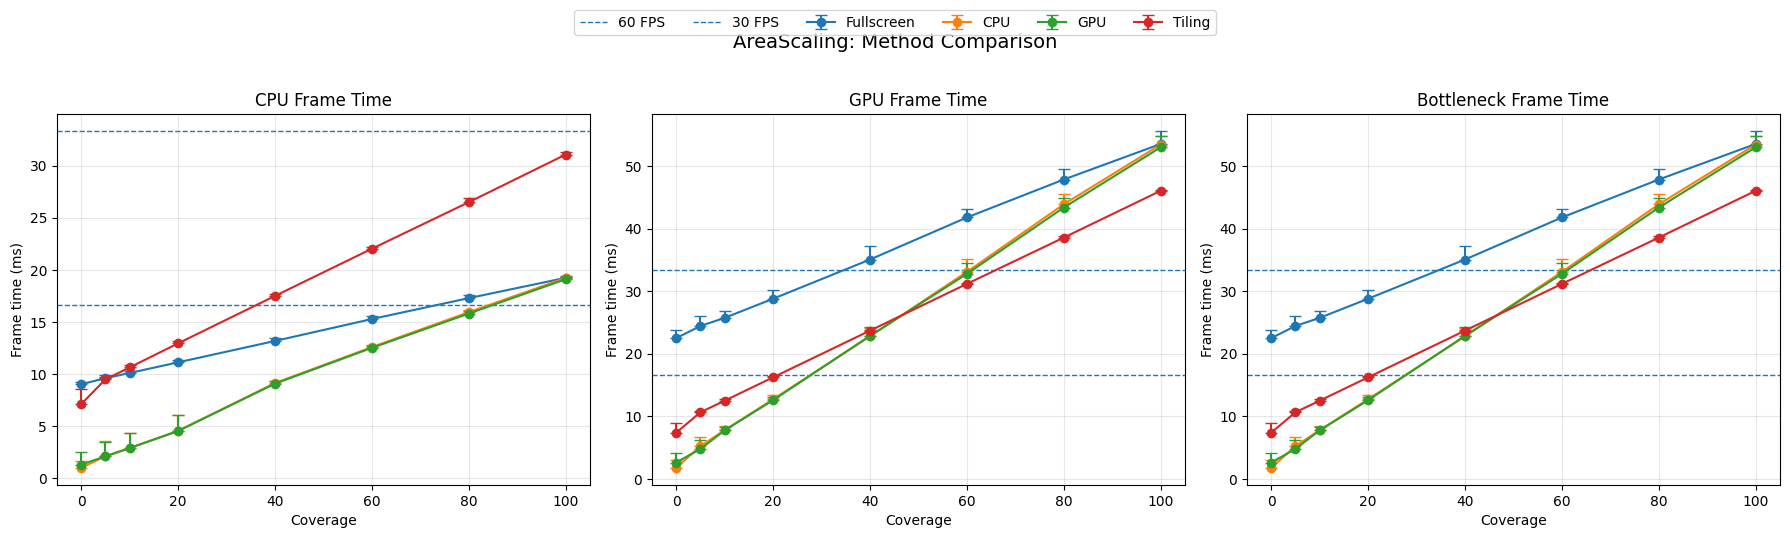

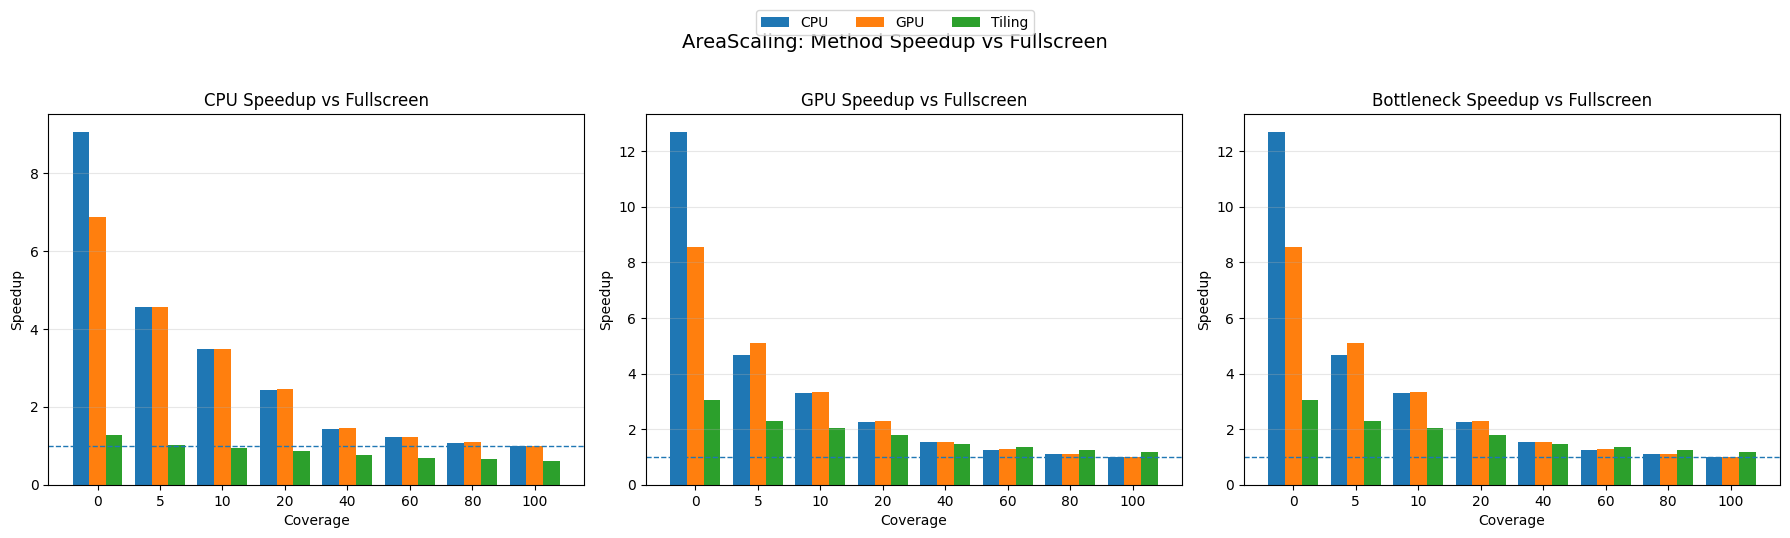


=== AreaScaling (Coverage) ===


--- Fullscreen ---
  Coverage |  GPU Med |  GPU P95 |  CPU Med |  CPU P95
------------------------------------------------------------
         0 |    22.50 |    23.74 |     9.02 |     9.26
         5 |    24.45 |    26.02 |     9.61 |     9.94
        10 |    25.75 |    26.90 |    10.11 |    10.27
        20 |    28.80 |    30.22 |    11.13 |    11.36
        40 |    35.07 |    37.29 |    13.18 |    13.47
        60 |    41.79 |    43.09 |    15.29 |    15.54
        80 |    47.86 |    49.54 |    17.30 |    17.55
       100 |    53.55 |    55.58 |    19.25 |    19.41

--- CPU ---
  Coverage |  GPU Med |  GPU P95 |  CPU Med |  CPU P95
------------------------------------------------------------
         0 |     1.77 |     3.10 |     1.00 |     1.70
         5 |     5.24 |     6.70 |     2.11 |     3.58
        10 |     7.80 |     8.44 |     2.90 |     4.34
        20 |    12.73 |    13.35 |     4.55 |     6.11
        40 |    22.79 |    24.10 |     9.1

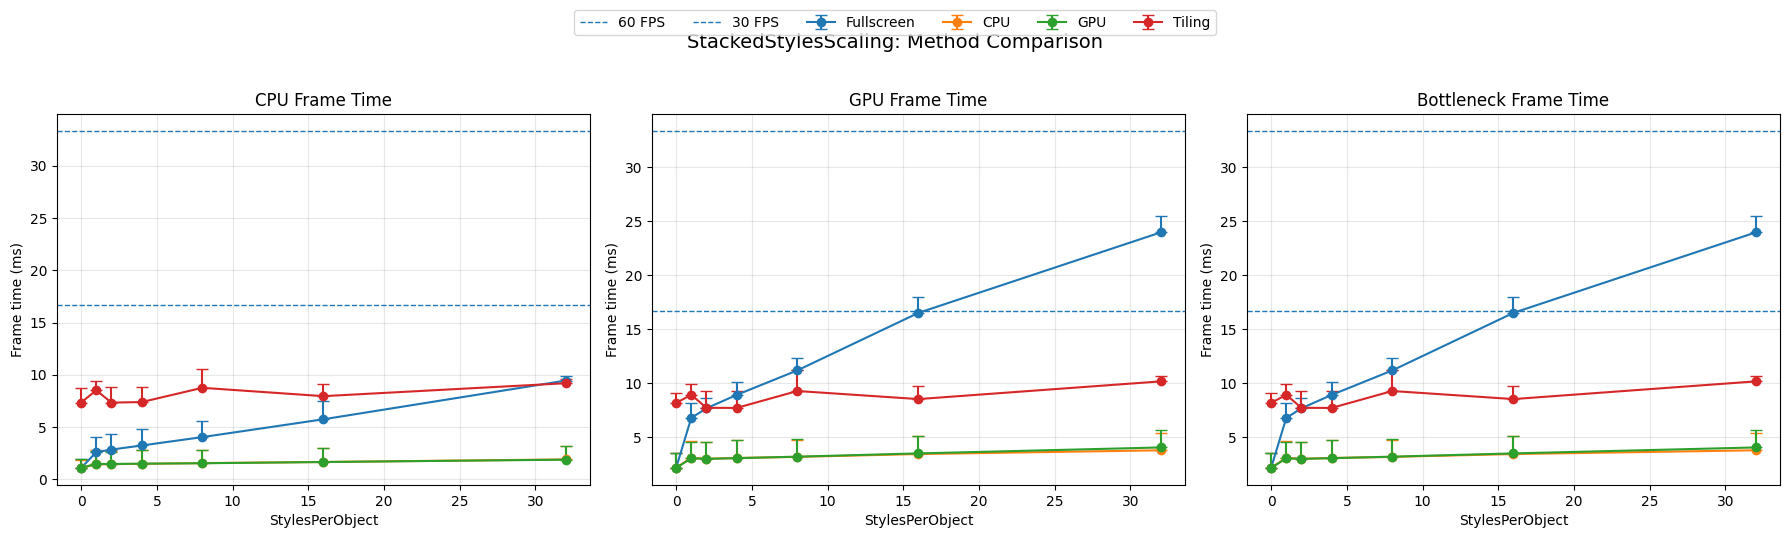

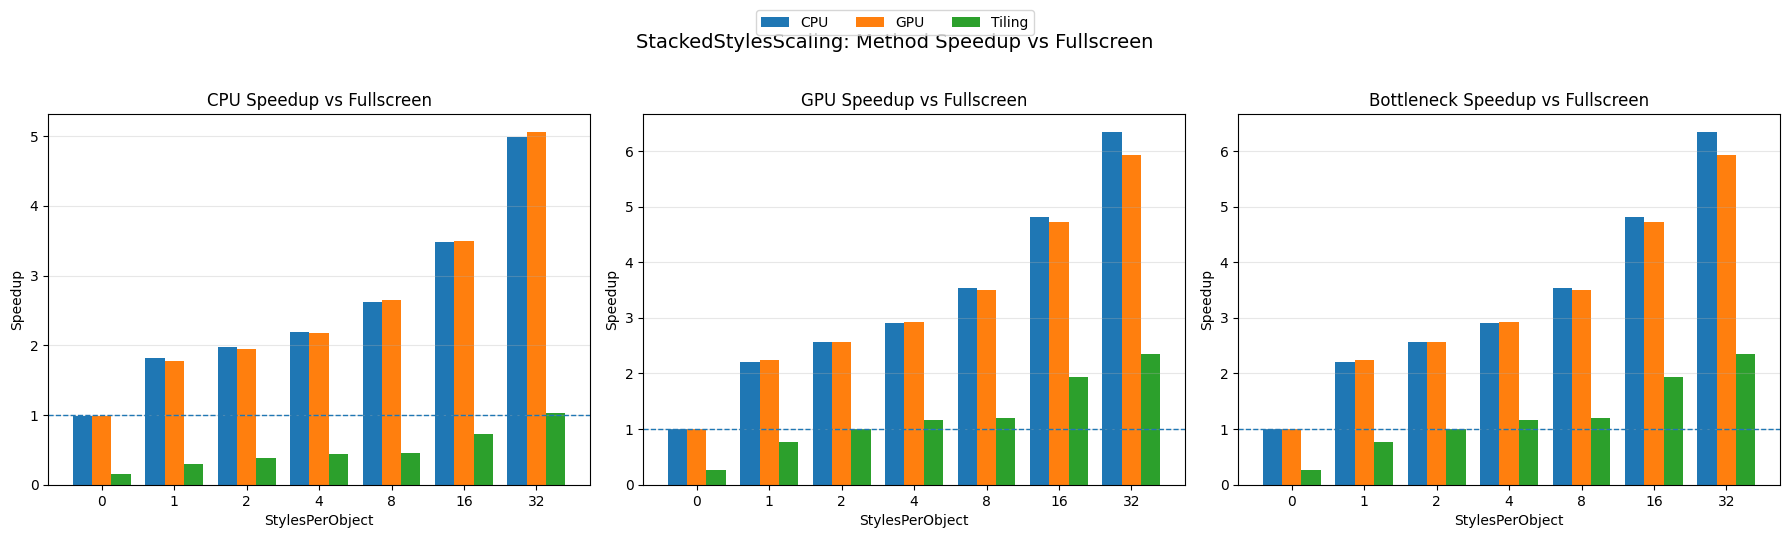


=== StackedStylesScaling (StylesPerObject) ===


--- Fullscreen ---
StylesPerObject |  GPU Med |  GPU P95 |  CPU Med |  CPU P95
------------------------------------------------------------
         0 |     2.15 |     3.55 |     1.08 |     1.93
         1 |     6.78 |     8.20 |     2.58 |     4.08
         2 |     7.66 |     8.60 |     2.83 |     4.33
         4 |     8.91 |    10.08 |     3.22 |     4.78
         8 |    11.18 |    12.31 |     4.03 |     5.54
        16 |    16.50 |    17.99 |     5.73 |     7.47
        32 |    23.96 |    25.50 |     9.44 |     9.89

--- CPU ---
StylesPerObject |  GPU Med |  GPU P95 |  CPU Med |  CPU P95
------------------------------------------------------------
         0 |     2.16 |     3.57 |     1.09 |     1.88
         1 |     3.07 |     4.67 |     1.42 |     2.75
         2 |     3.00 |     4.59 |     1.44 |     2.74
         4 |     3.07 |     4.70 |     1.47 |     2.77
         8 |     3.17 |     4.77 |     1.54 |     2.81
        16 |    

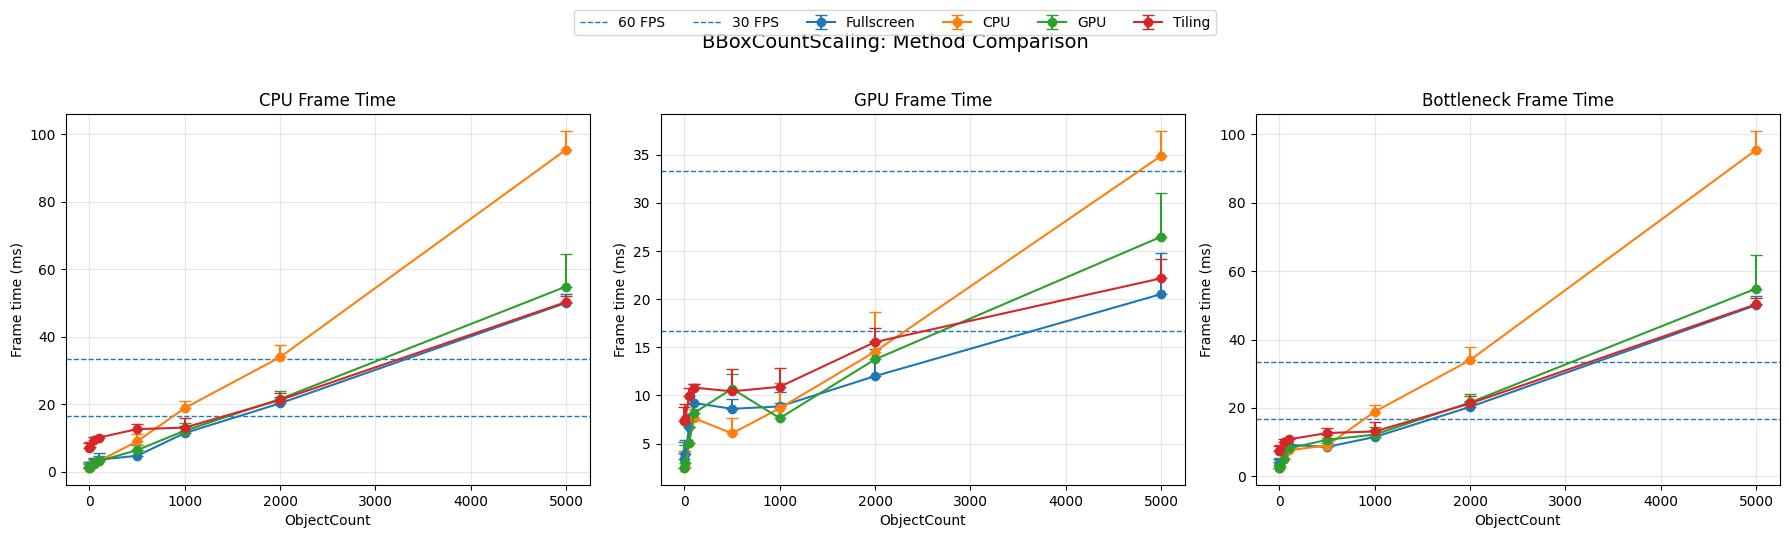

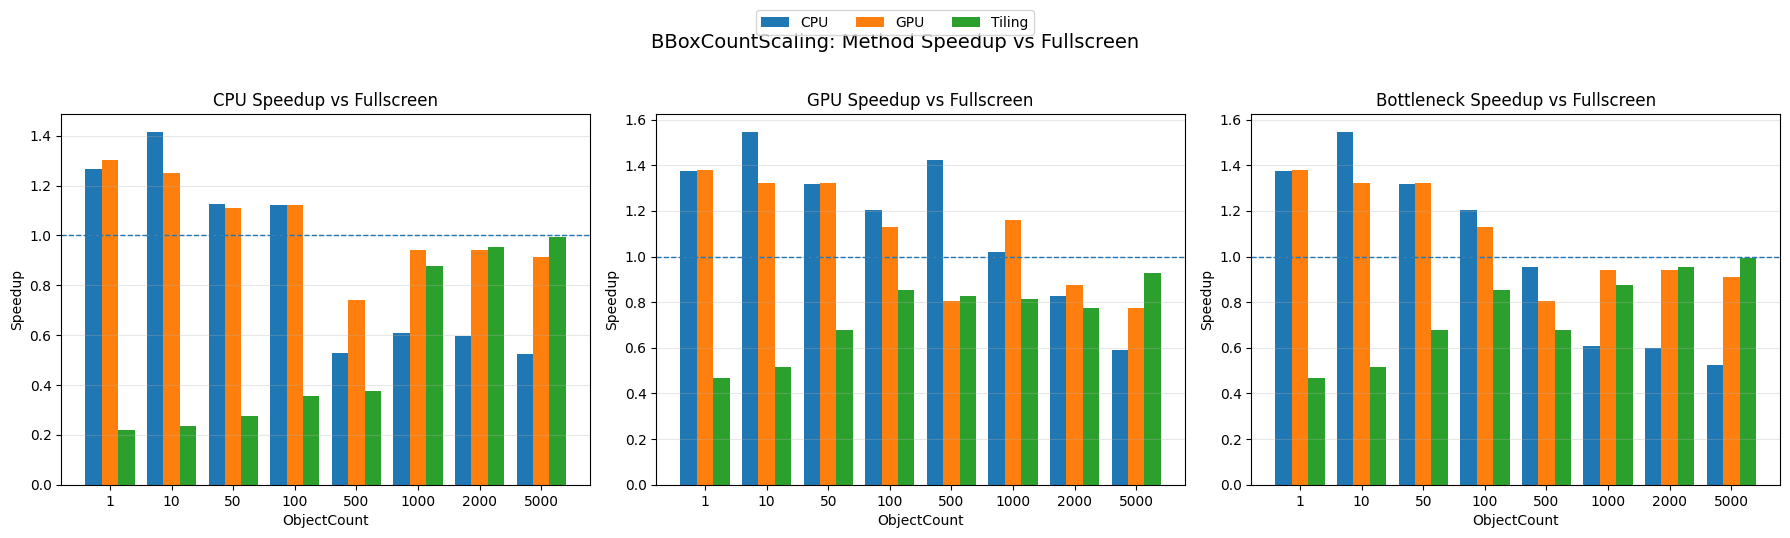

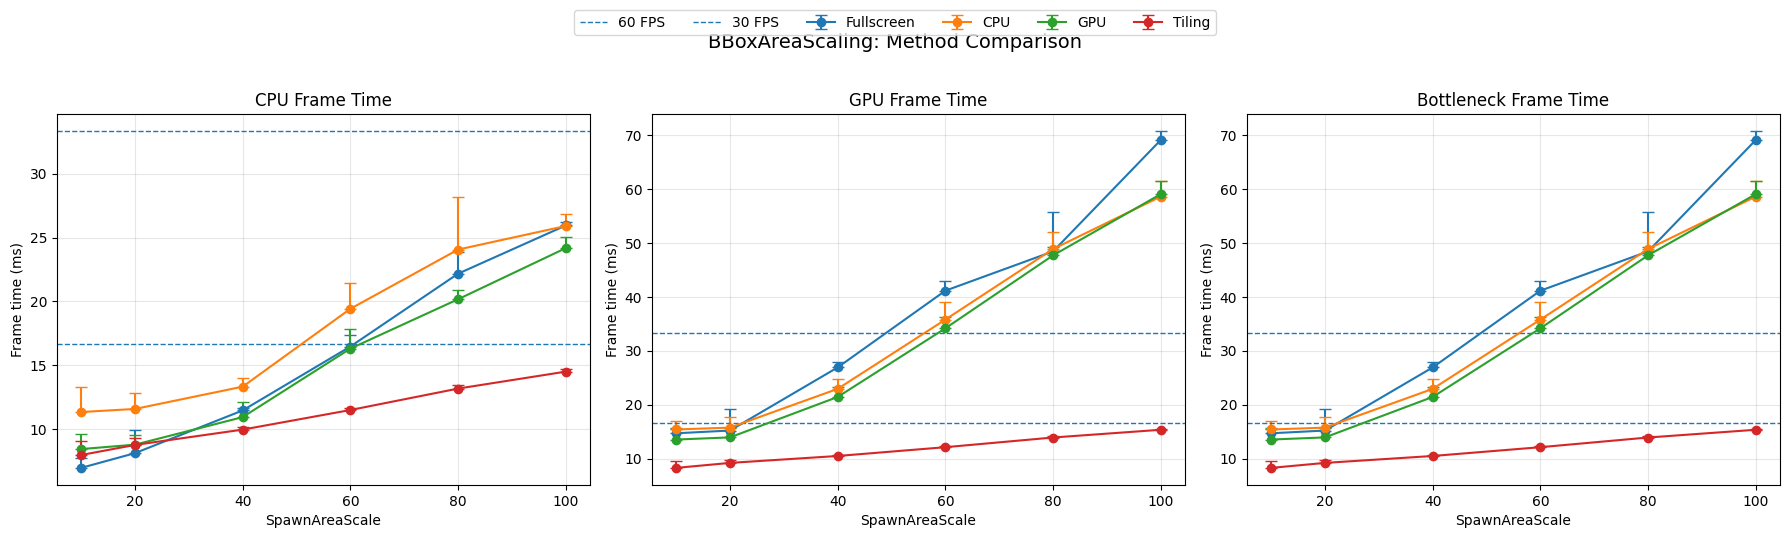

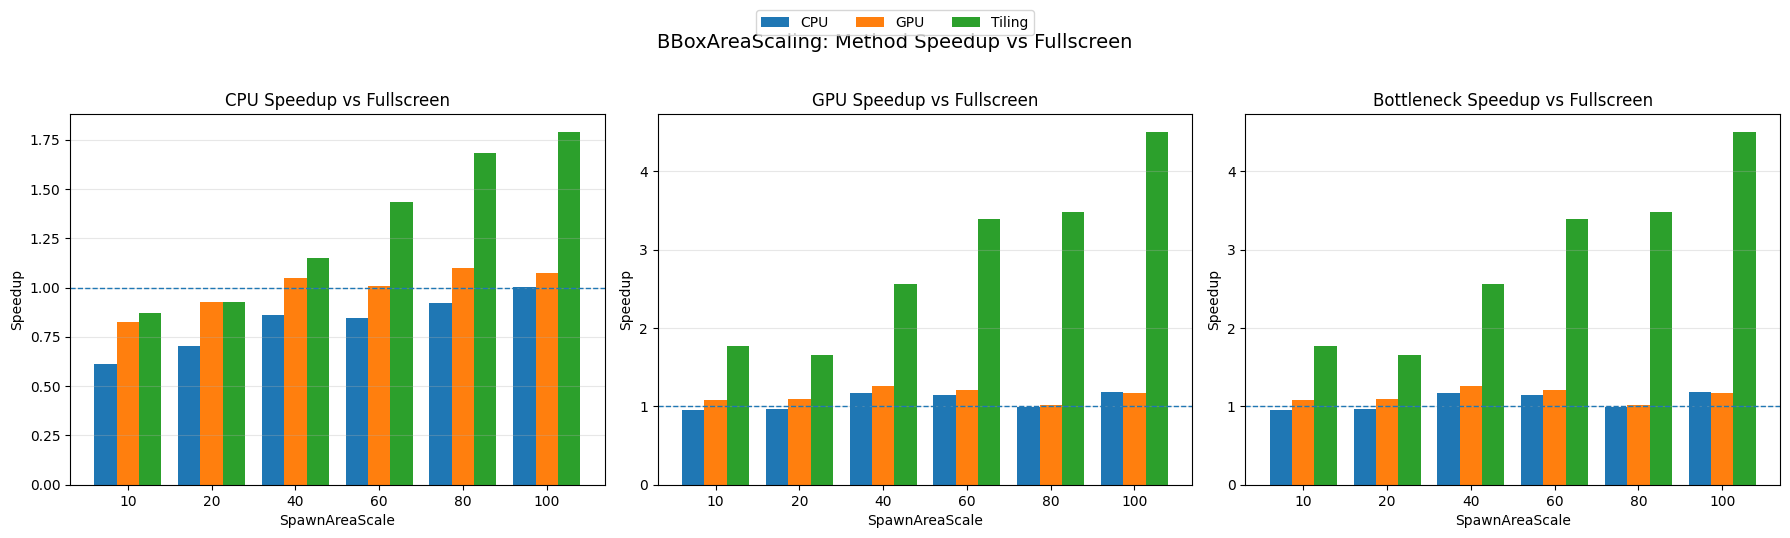

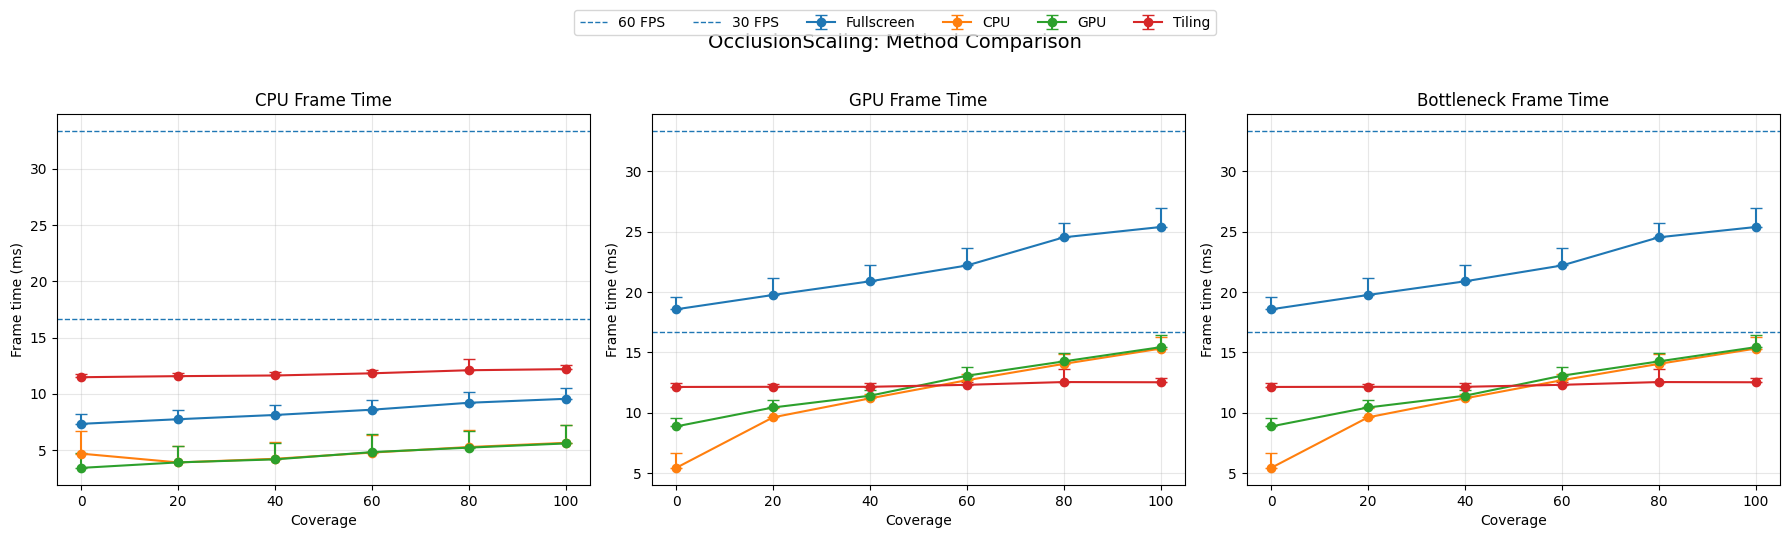

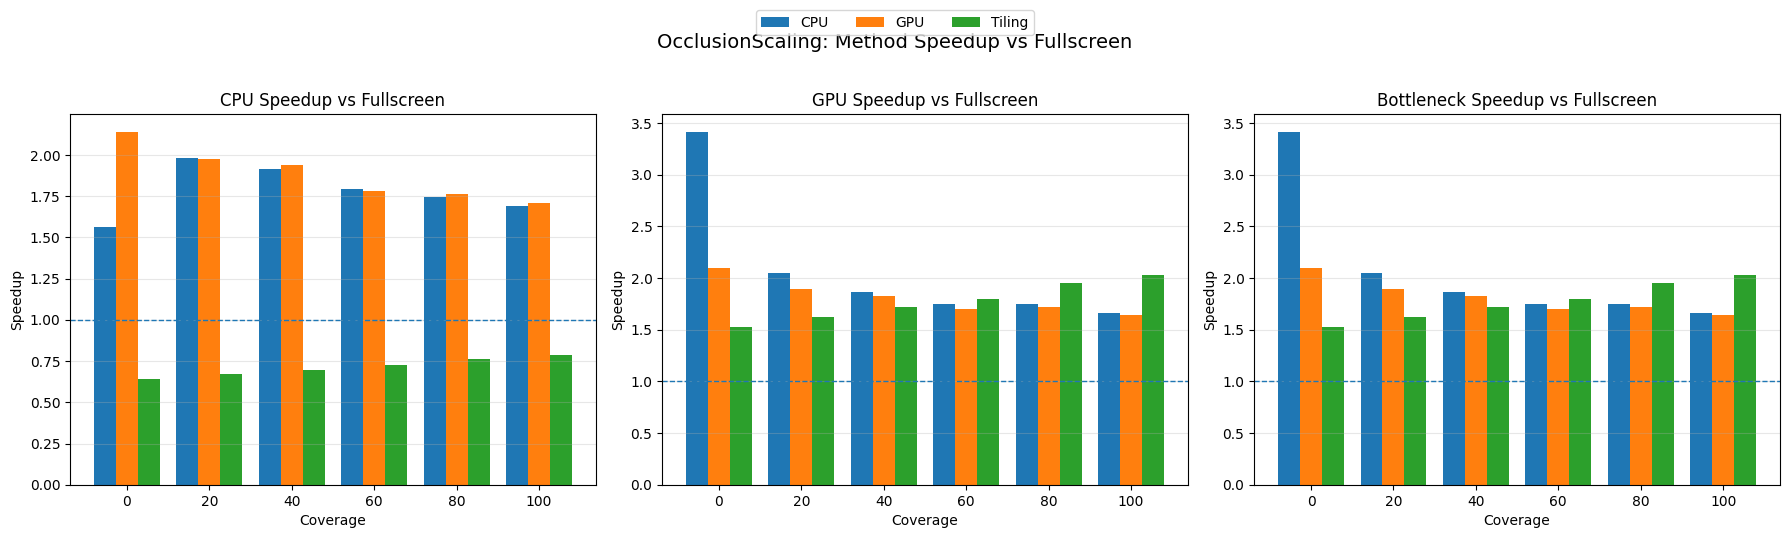

In [742]:
plot_method_graph_row(df, family="AreaScaling", variable="Coverage")
plot_method_speedup_bars_row(df, family="AreaScaling", variable="Coverage")
print_values_on_graph(df, family="AreaScaling", variable="Coverage")
compute_scaling(df, family="AreaScaling", variable="Coverage")

plot_method_graph_row(df, family="StackedStylesScaling", variable="StylesPerObject")
plot_method_speedup_bars_row(df, family="StackedStylesScaling", variable="StylesPerObject")
print_values_on_graph(df, family="StackedStylesScaling", variable="StylesPerObject")
compute_scaling(df, family="StackedStylesScaling", variable="StylesPerObject")

plot_method_graph_row(df, family="BBoxCountScaling", variable="ObjectCount")
plot_method_speedup_bars_row(df, family="BBoxCountScaling", variable="ObjectCount")

# plot_method_graph_row(df, family="BBoxCountScaling", variable="ObjectCount", style_variant="RandomSingleStyle")
# plot_method_speedup_bar_row(df, family="BBoxCountScaling", variable="ObjectCount", style_variant="RandomSingleStyle")

plot_method_graph_row(df, family="BBoxAreaScaling", variable="SpawnAreaScale")
plot_method_speedup_bars_row(df, family="BBoxAreaScaling", variable="SpawnAreaScale")

plot_method_graph_row(df, family="OcclusionScaling", variable="Coverage")
plot_method_speedup_bars_row(df, family="OcclusionScaling", variable="Coverage")

### MERGE ABLATIONS

In [ ]:
df["ablation_family"] = (
    df["base_test_name"]
    .astype(str)
    .str.replace(r"_CPU$", "", regex=True)
    .str.replace(r"_GPU$", "", regex=True)
)

merge_df = df[df["merge"].notna()].copy()

In [ ]:
def plot_merge_ablation_row_combined(
    df,
    base_test_name,
    variable,
    shader_variant=None,
    title=None,
):
    subset = df[
        (df["ablation_family"] == base_test_name) &
        (df["variable"] == variable) &
        (df["render_mode"].isin(["CPU", "GPU"])) &
        (df["merge"].notna())
    ].copy()

    if shader_variant is not None:
        subset = subset[subset["shader_variant"] == shader_variant]

    if subset.empty:
        print("No merge ablation data.")
        return

    # collapse duplicates
    subset = (
        subset
        .groupby(["value", "render_mode", "merge_label"], as_index=False)
        .agg({
            "median_cpu_ms": "median",
            "p95_cpu_ms": "median",
            "median_gpu_ms": "median",
            "p95_gpu_ms": "median",
        })
        .sort_values(["value", "render_mode", "merge_label"])
    )

    # ---- 3 PANELS ----
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    panels = [
        ("cpu", "CPU Frame Time"),
        ("gpu", "GPU Frame Time"),
        ("bottleneck", "Bottleneck Frame Time"),
    ]

    color_map = {
        "CPU": "tab:blue",
        "GPU": "tab:orange"
    }

    linestyle_map = {
        "NoMerge": "-",
        "Merge": "--"
    }

    for ax, (metric, panel_title) in zip(axes, panels):

        for render_mode in ["CPU", "GPU"]:
            for merge_label in ["NoMerge", "Merge"]:

                line_df = subset[
                    (subset["render_mode"] == render_mode) &
                    (subset["merge_label"] == merge_label)
                ].sort_values("value")

                if line_df.empty:
                    continue

                x = line_df["value"].values

                # ---- SELECT METRIC ----
                if metric == "cpu":
                    median = line_df["median_cpu_ms"].values
                    p95 = line_df["p95_cpu_ms"].values

                elif metric == "gpu":
                    median = line_df["median_gpu_ms"].values
                    p95 = line_df["p95_gpu_ms"].values

                else:  # bottleneck
                    cpu_med = line_df["median_cpu_ms"].values
                    gpu_med = line_df["median_gpu_ms"].values
                    cpu_p95 = line_df["p95_cpu_ms"].values
                    gpu_p95 = line_df["p95_gpu_ms"].values

                    median = np.maximum(cpu_med, gpu_med)
                    p95 = np.maximum(cpu_p95, gpu_p95)

                lower_err = np.zeros_like(median)
                upper_err = p95 - median

                ax.errorbar(
                    x,
                    median,
                    yerr=[lower_err, upper_err],
                    marker="o",
                    capsize=4,
                    color=color_map[render_mode],
                    linestyle=linestyle_map[merge_label],
                    label=f"{render_mode} / {merge_label}"
                )

        # frame budget
        ax.axhline(16.67, linestyle="--", linewidth=1, color="gray")
        ax.axhline(33.33, linestyle="--", linewidth=1, color="gray")

        ax.set_title(panel_title)
        ax.set_xlabel(variable)
        ax.set_ylabel("Frame time (ms)")
        ax.grid(True, alpha=0.3)

    if title is None:
        title = f"{base_test_name}: Merge Ablation"
        if shader_variant:
            title += f" ({shader_variant})"

    fig.suptitle(title, y=1.02, fontsize=14)

    # single shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08))

    plt.tight_layout()
    plt.show()

def plot_merge_speedup_grouped_bars(
    df,
    family,
    variable,
    render_mode="GPU",              # "GPU" or "CPU"
    metric="gpu",                   # "gpu", "cpu", or "bottleneck"
    style_variant=None,
    title=None,
):
    local_df = df.copy()

    # normalise ablation family
    local_df["ablation_family"] = (
        local_df["base_test_name"]
        .astype(str)
        .str.replace(r"_CPU$", "", regex=True)
        .str.replace(r"_GPU$", "", regex=True)
    )

    subset = local_df[
        (local_df["ablation_family"] == family) &
        (local_df["variable"] == variable) &
        (local_df["render_mode"] == render_mode) &
        (local_df["merge_label"].isin(["NoMerge", "Merge"])) &
        (local_df["shader_variant"].isin(["Default", "Heavy"]))
    ].copy()

    if style_variant is not None:
        subset = subset[subset["style_variant"] == style_variant]

    if subset.empty:
        print("No matching merge ablation data found.")
        return

    # aggregate repeated rows
    subset = (
        subset
        .groupby(["value", "shader_variant", "merge_label"], as_index=False)
        .agg({
            "median_cpu_ms": "median",
            "median_gpu_ms": "median",
            "p95_cpu_ms": "median",
            "p95_gpu_ms": "median",
        })
        .sort_values(["value", "shader_variant", "merge_label"])
    )

    # choose metric
    if metric == "cpu":
        subset["metric_median"] = subset["median_cpu_ms"]
    elif metric == "gpu":
        subset["metric_median"] = subset["median_gpu_ms"]
    elif metric == "bottleneck":
        subset["metric_median"] = np.maximum(
            subset["median_cpu_ms"],
            subset["median_gpu_ms"]
        )
    else:
        raise ValueError("metric must be 'cpu', 'gpu', or 'bottleneck'")

    # pivot to get NoMerge and Merge side by side
    pivot = (
        subset
        .pivot(index=["value", "shader_variant"], columns="merge_label", values="metric_median")
        .reset_index()
    )

    pivot = pivot.dropna(subset=["NoMerge", "Merge"]).copy()

    if pivot.empty:
        print("No paired Merge/NoMerge rows found.")
        return

    pivot["speedup"] = pivot["NoMerge"] / pivot["Merge"]

    x_values = sorted(pivot["value"].unique())
    shader_order = ["Default", "Heavy"]
    width = 0.35
    x = np.arange(len(x_values))

    plt.figure(figsize=(10, 5))

    for i, shader in enumerate(shader_order):
        shader_df = (
            pivot[pivot["shader_variant"] == shader]
            .set_index("value")
            .reindex(x_values)
            .reset_index()
        )

        offsets = x + (i - 0.5) * width

        plt.bar(
            offsets,
            shader_df["speedup"].values,
            width=width,
            label=shader
        )

    plt.axhline(1.0, linestyle="--", linewidth=1)
    plt.xticks(x, x_values)
    plt.xlabel(variable)
    plt.ylabel(f"NoMerge / Merge speedup ({metric.upper()})")
    plt.grid(True, axis="y", alpha=0.3)

    if title is None:
        extra = f" ({style_variant})" if style_variant is not None else ""
        title = f"{family}{extra}: {render_mode} Merge Speedup"

    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [ ]:
    
def plot_merge_speedup_grouped_bars_row(
    df,
    family,
    variable,
    render_mode="GPU",
    style_variant=None,
    title=None,
):
    local_df = df.copy()

    # normalise family
    local_df["ablation_family"] = (
        local_df["base_test_name"]
        .astype(str)
        .str.replace(r"_CPU$", "", regex=True)
        .str.replace(r"_GPU$", "", regex=True)
    )

    subset = local_df[
        (local_df["ablation_family"] == family) &
        (local_df["variable"] == variable) &
        (local_df["render_mode"] == render_mode) &
        (local_df["merge_label"].isin(["NoMerge", "Merge"])) &
        (local_df["shader_variant"].isin(["Default", "Heavy"]))
    ].copy()

    if style_variant is not None:
        subset = subset[subset["style_variant"] == style_variant]

    if subset.empty:
        print("No matching merge ablation data found.")
        return

    # aggregate
    subset = (
        subset
        .groupby(["value", "shader_variant", "merge_label"], as_index=False)
        .agg({
            "median_cpu_ms": "median",
            "median_gpu_ms": "median",
            "p95_cpu_ms": "median",
            "p95_gpu_ms": "median",
        })
    )

    # compute metrics
    subset["cpu"] = subset["median_cpu_ms"]
    subset["gpu"] = subset["median_gpu_ms"]
    subset["bottleneck"] = np.maximum(
        subset["median_cpu_ms"],
        subset["median_gpu_ms"]
    )

    # pivot once per metric later
    metrics = ["cpu", "gpu", "bottleneck"]
    panel_titles = ["CPU", "GPU", "Bottleneck"]

    x_values = sorted(subset["value"].unique())
    shader_order = ["Default", "Heavy"]
    width = 0.35
    x = np.arange(len(x_values))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    for ax, metric, panel_title in zip(axes, metrics, panel_titles):

        pivot = (
            subset
            .pivot(index=["value", "shader_variant"], columns="merge_label", values=metric)
            .reset_index()
        )

        pivot = pivot.dropna(subset=["NoMerge", "Merge"]).copy()

        if pivot.empty:
            continue

        pivot["speedup"] = pivot["NoMerge"] / pivot["Merge"]

        for i, shader in enumerate(shader_order):
            shader_df = (
                pivot[pivot["shader_variant"] == shader]
                .set_index("value")
                .reindex(x_values)
                .reset_index()
            )

            offsets = x + (i - 0.5) * width

            ax.bar(
                offsets,
                shader_df["speedup"].values,
                width=width,
                label=shader
            )

        ax.axhline(1.0, linestyle="--", linewidth=1)
        ax.set_title(panel_title)
        ax.set_xlabel(variable)
        ax.set_ylabel("NoMerge / Merge Speedup")
        ax.set_xticks(x)
        ax.set_xticklabels(x_values)
        ax.grid(True, axis="y", alpha=0.3)

    if title is None:
        extra = f" ({style_variant})" if style_variant is not None else ""
        title = f"{family}{extra}: {render_mode} Merge Speedup"

    fig.suptitle(title, y=1.02, fontsize=14)

    # shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.08))

    plt.tight_layout()
    plt.show()

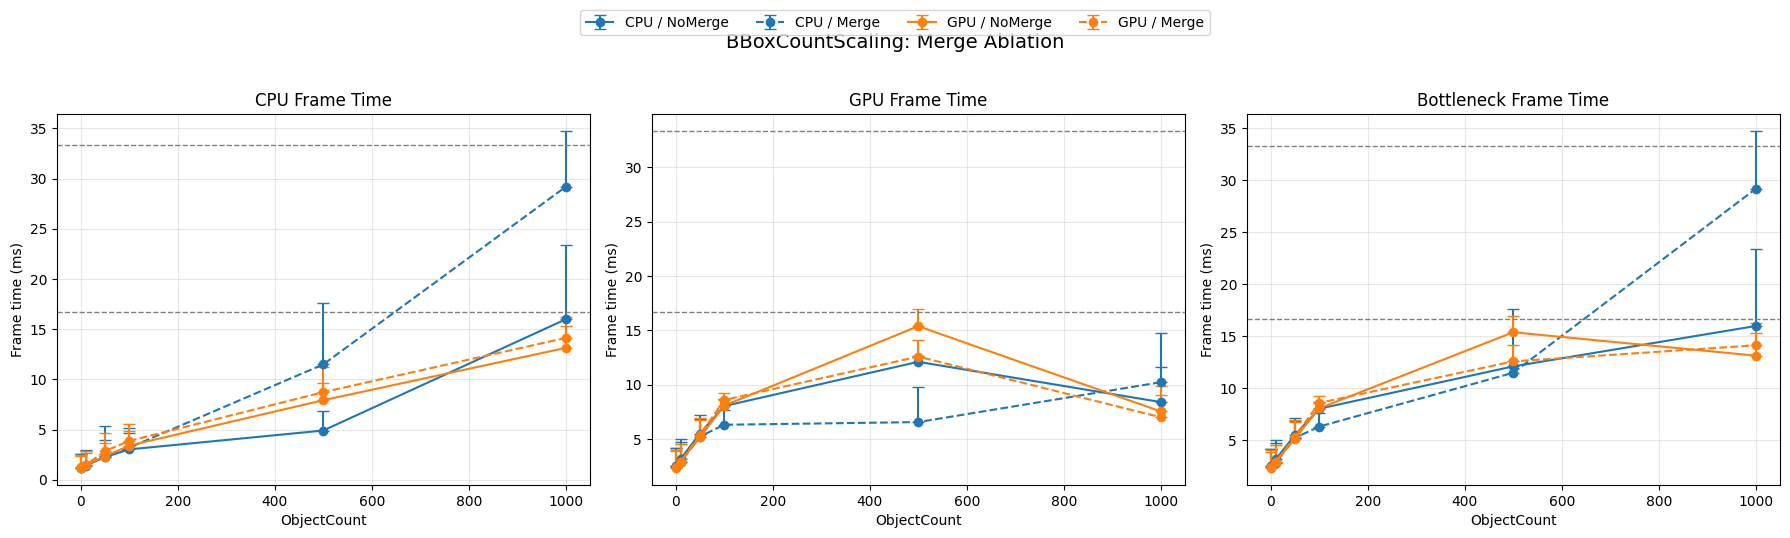

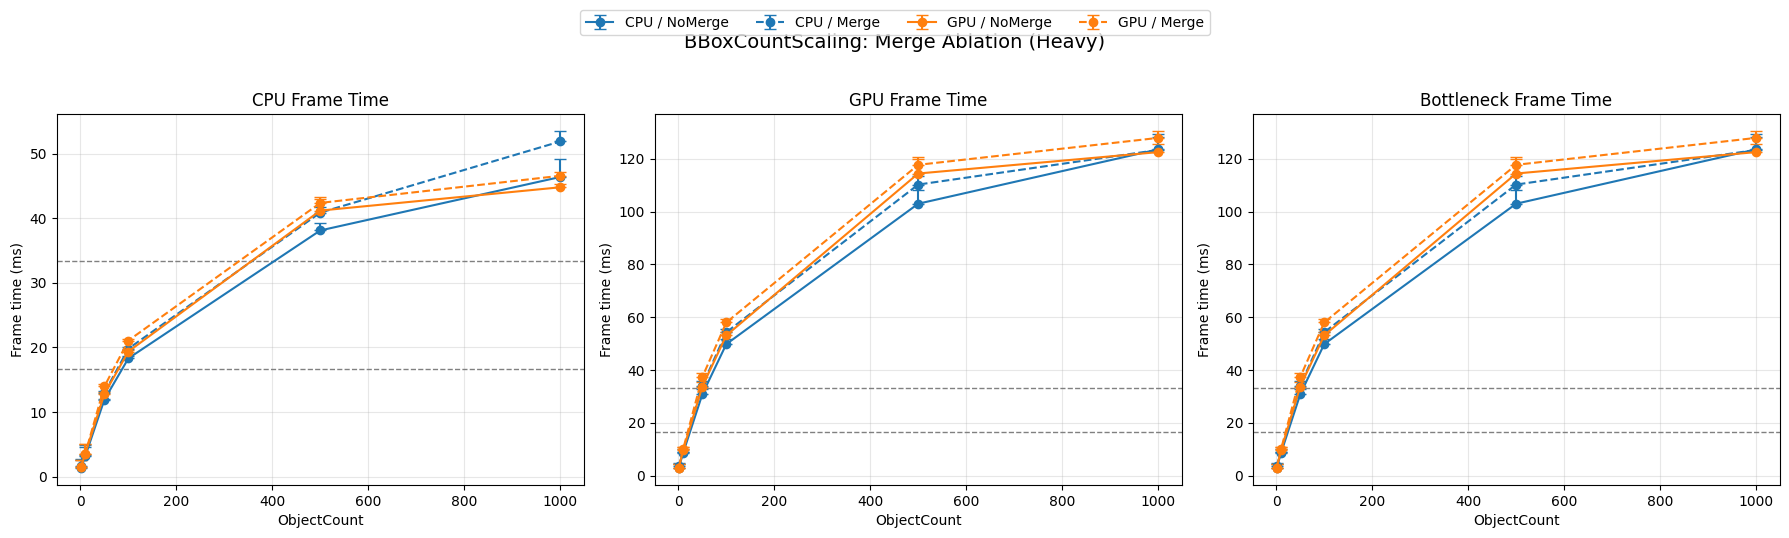

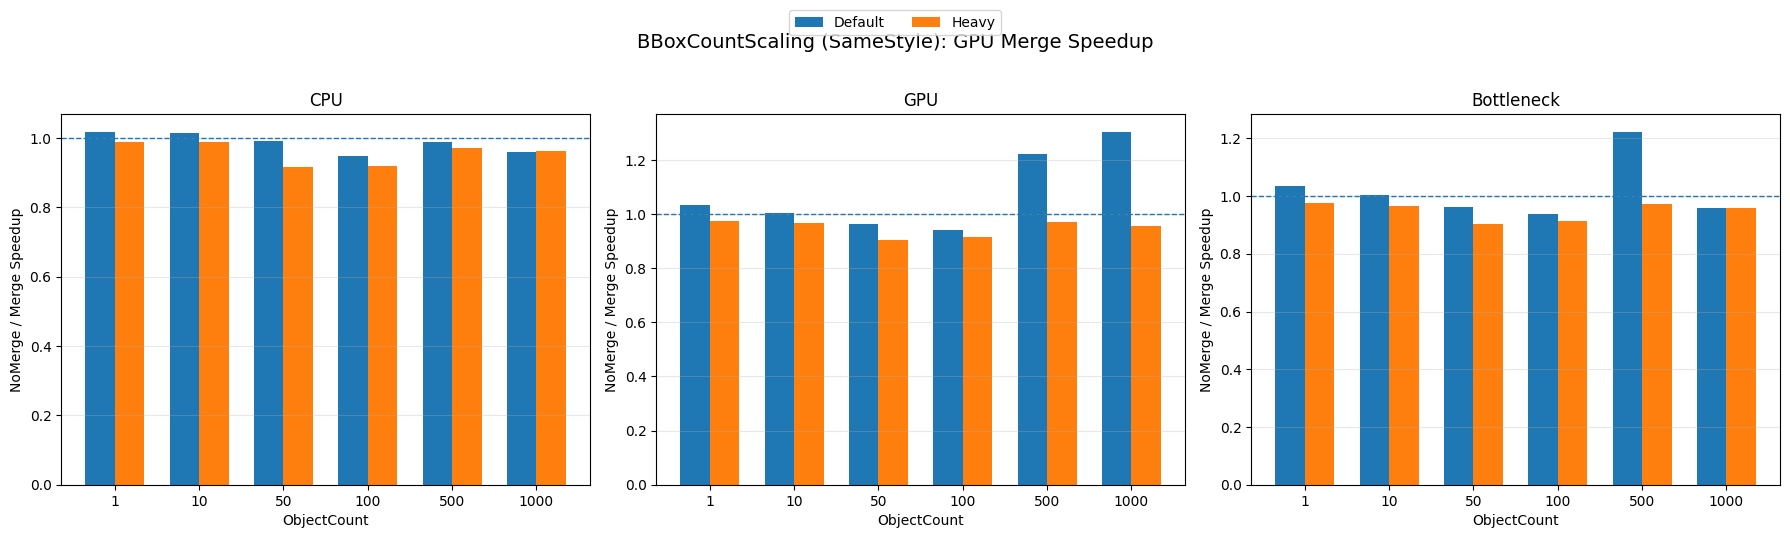

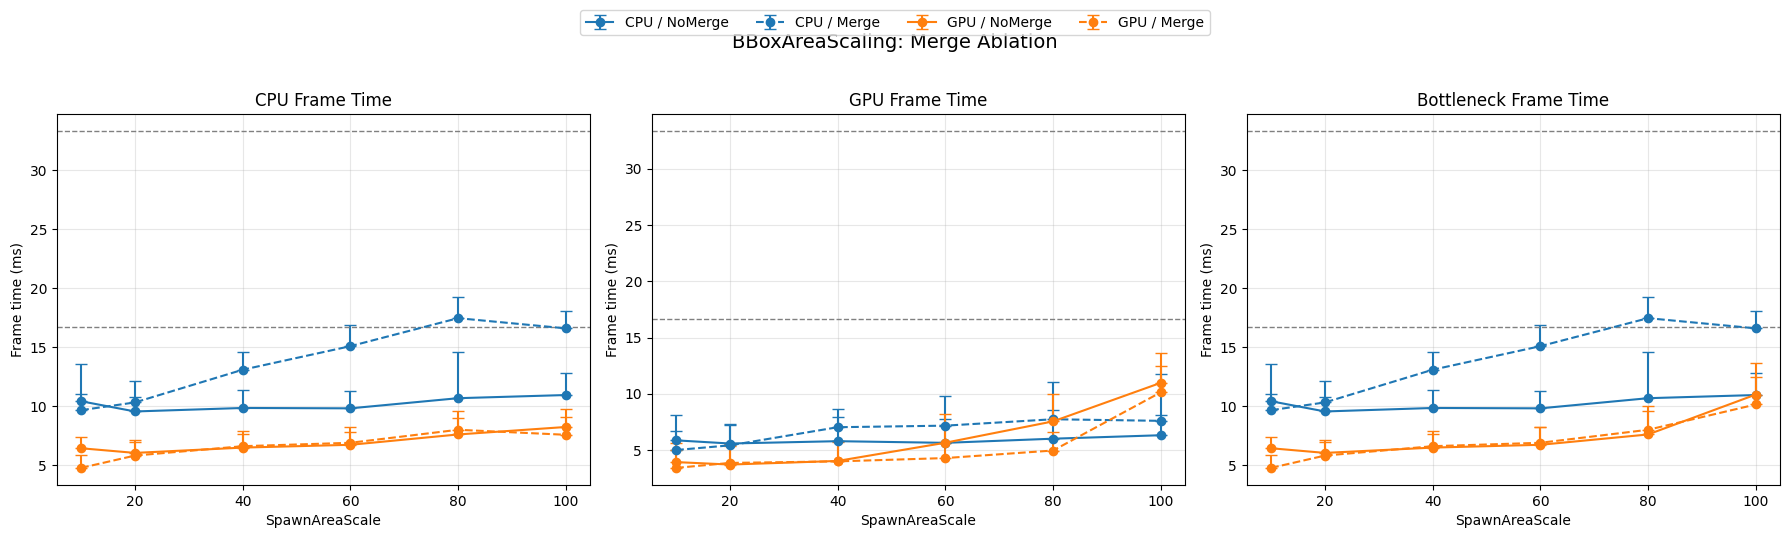

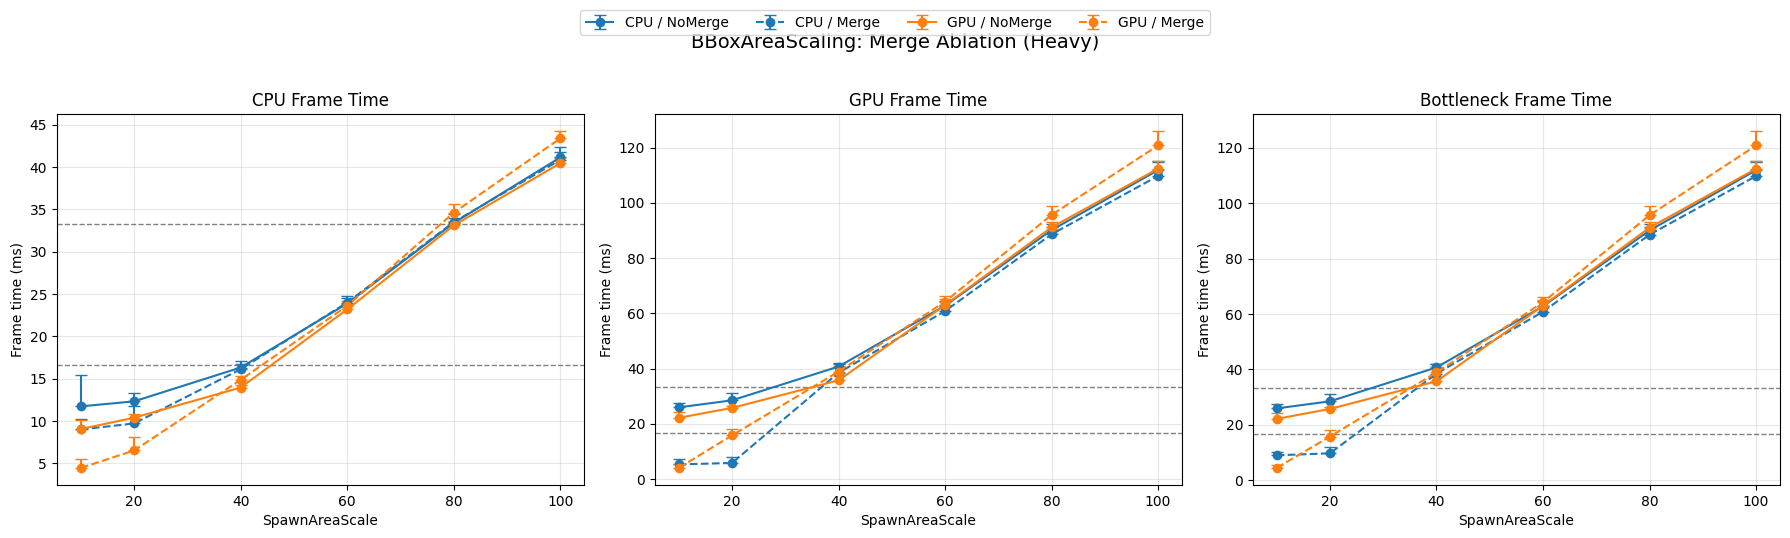

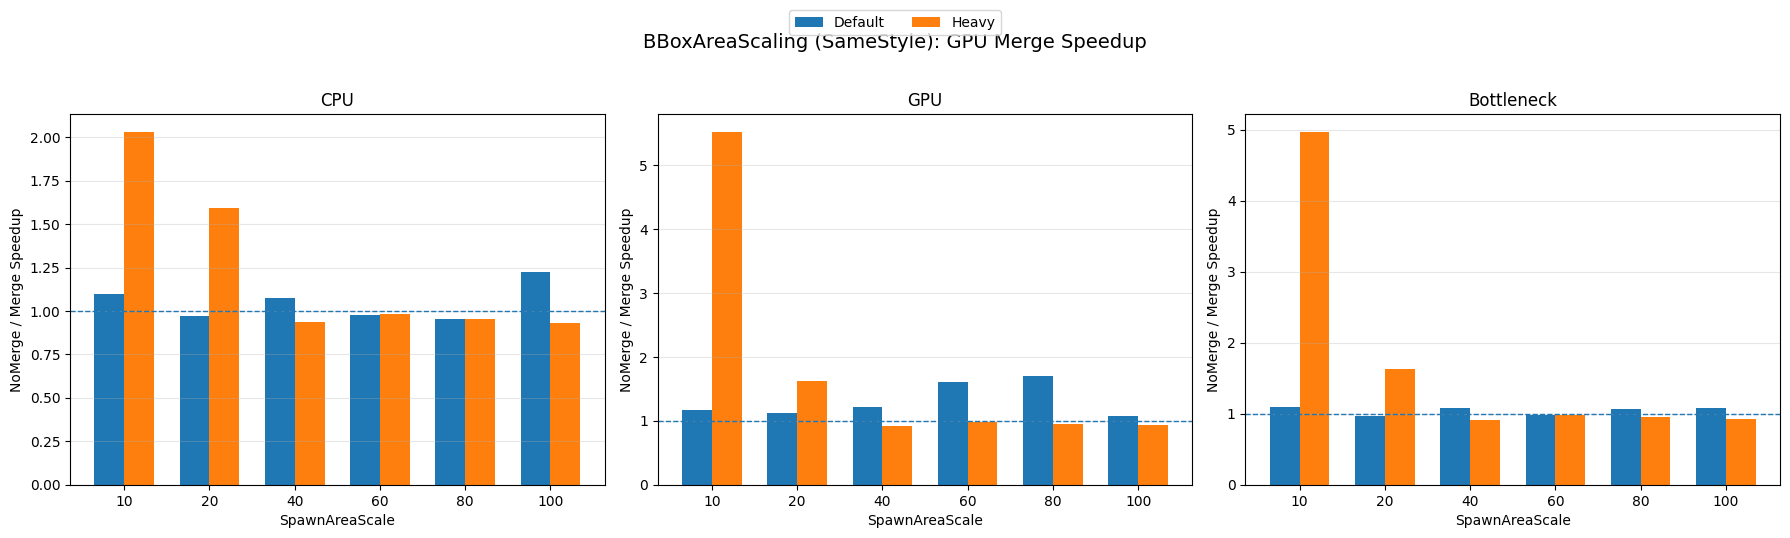

In [728]:
plot_merge_ablation_row_combined(merge_df, "BBoxCountScaling", "ObjectCount")

plot_merge_ablation_row_combined(merge_df, "BBoxCountScaling", "ObjectCount", shader_variant="Heavy")

plot_merge_speedup_grouped_bars_row(df, family="BBoxCountScaling", variable="ObjectCount", render_mode="GPU", style_variant="SameStyle")

plot_merge_ablation_row_combined(merge_df, "BBoxAreaScaling", "SpawnAreaScale")

plot_merge_ablation_row_combined(merge_df,"BBoxAreaScaling","SpawnAreaScale",shader_variant="Heavy")

plot_merge_speedup_grouped_bars_row(df, family="BBoxAreaScaling", variable="SpawnAreaScale", render_mode="GPU", style_variant="SameStyle")

### Occlusion Ablation

In [ ]:
occlusion_df = df[df["occlusion"].notna()].copy()

In [ ]:
def plot_occlusion_ablation_row_combined(
    df,
    base_test_name,
    variable,
    shader_variant=None,
    style_variant=None,
    N=None,
    K=None,
    styles_per_object=None,
    title=None,
):
    subset = df[
        (df["ablation_family"] == base_test_name) &
        (df["variable"] == variable) &
        (df["render_mode"].isin(["CPU", "GPU"])) &
        (df["occlusion"].notna())
    ].copy()

    if shader_variant is not None:
        subset = subset[subset["shader_variant"] == shader_variant]

    if style_variant is not None:
        subset = subset[subset["style_variant"] == style_variant]

    if N is not None:
        subset = subset[subset["N"] == N]

    if K is not None:
        subset = subset[subset["K"] == K]

    if styles_per_object is not None:
        subset = subset[subset["styles_per_object"] == styles_per_object]

    if subset.empty:
        print("No occlusion ablation data.")
        return

    subset = (
        subset
        .groupby(["value", "render_mode", "occlusion_label"], as_index=False)
        .agg({
            "median_cpu_ms": "median",
            "p95_cpu_ms": "median",
            "median_gpu_ms": "median",
            "p95_gpu_ms": "median",
        })
        .sort_values(["value", "render_mode", "occlusion_label"])
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    panels = [
        ("cpu", "CPU Frame Time"),
        ("gpu", "GPU Frame Time"),
        ("bottleneck", "Bottleneck Frame Time"),
    ]

    color_map = {
        "CPU": "tab:blue",
        "GPU": "tab:orange"
    }

    linestyle_map = {
        "NoOcclusion": "-",
        "Occlusion": "--"
    }

    for ax, (metric, panel_title) in zip(axes, panels):
        for render_mode in ["CPU", "GPU"]:
            for occlusion_label in ["NoOcclusion", "Occlusion"]:
                line_df = subset[
                    (subset["render_mode"] == render_mode) &
                    (subset["occlusion_label"] == occlusion_label)
                ].sort_values("value")

                if line_df.empty:
                    continue

                x = line_df["value"].values

                if metric == "cpu":
                    median = line_df["median_cpu_ms"].values
                    p95 = line_df["p95_cpu_ms"].values
                elif metric == "gpu":
                    median = line_df["median_gpu_ms"].values
                    p95 = line_df["p95_gpu_ms"].values
                else:
                    cpu_med = line_df["median_cpu_ms"].values
                    gpu_med = line_df["median_gpu_ms"].values
                    cpu_p95 = line_df["p95_cpu_ms"].values
                    gpu_p95 = line_df["p95_gpu_ms"].values
                    median = np.maximum(cpu_med, gpu_med)
                    p95 = np.maximum(cpu_p95, gpu_p95)

                lower_err = np.zeros_like(median)
                upper_err = p95 - median

                ax.errorbar(
                    x,
                    median,
                    yerr=[lower_err, upper_err],
                    marker="o",
                    capsize=4,
                    color=color_map[render_mode],
                    linestyle=linestyle_map[occlusion_label],
                    label=f"{render_mode} / {occlusion_label}"
                )

        ax.axhline(16.67, linestyle="--", linewidth=1, color="gray")
        ax.axhline(33.33, linestyle="--", linewidth=1, color="gray")
        ax.set_title(panel_title)
        ax.set_xlabel(variable)
        ax.set_ylabel("Frame time (ms)")
        ax.grid(True, alpha=0.3)

    if title is None:
        title = f"{base_test_name}: Occlusion Ablation"
        extras = []
        if style_variant is not None:
            extras.append(style_variant)
        if N is not None:
            extras.append(f"N={N}")
        if K is not None:
            extras.append(f"K={K}")
        if styles_per_object is not None:
            extras.append(f"S={styles_per_object}")
        if shader_variant is not None:
            extras.append(shader_variant)

        if extras:
            title += " (" + ", ".join(extras) + ")"

    fig.suptitle(title, y=1.02, fontsize=14)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08))
    plt.tight_layout()
    plt.show()

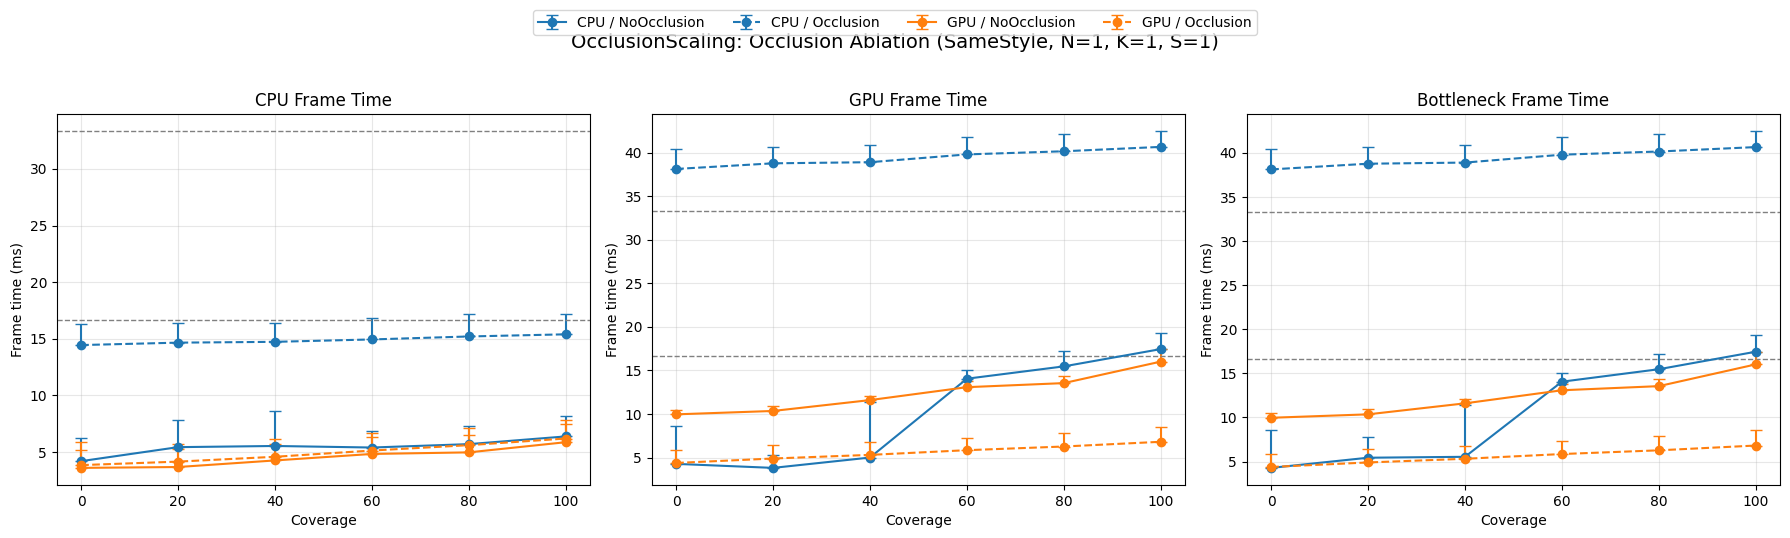

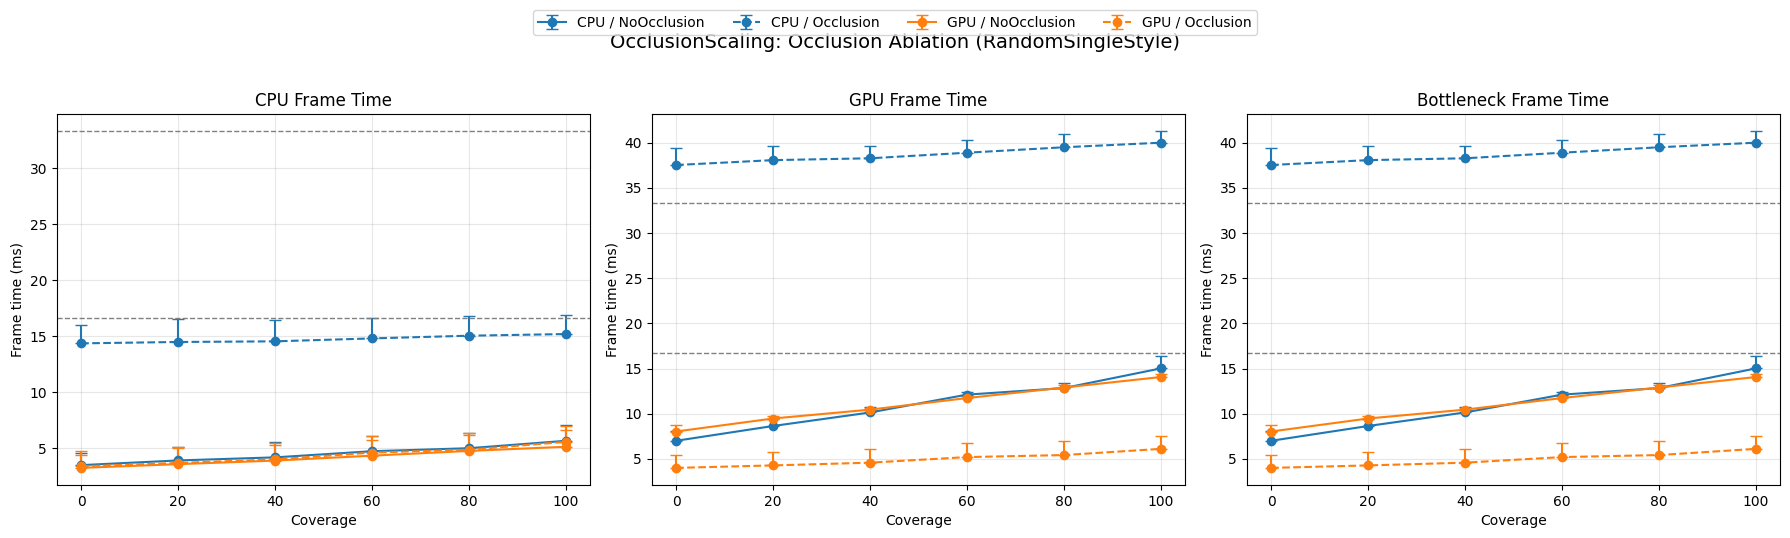

In [ ]:
plot_occlusion_ablation_row_combined(
    df,
    base_test_name="OcclusionScaling",
    variable="Coverage",
    style_variant="SameStyle",
    N=1,
    K=1,
    styles_per_object=1
)
plot_occlusion_ablation_row_combined(
    df,
    base_test_name="OcclusionScaling",
    variable="Coverage",
    style_variant="RandomSingleStyle"
)

### Tiling Ablation

In [ ]:
tiling_ablation_df = df.copy()

# detect explicit tile-size ablation rows from test_name
tiling_ablation_df["tile_size"] = (
    tiling_ablation_df["test_name"]
    .astype(str)
    .str.extract(r"Tiling(8|16|32|64)$")[0]
)

tiling_ablation_df["tile_size"] = pd.to_numeric(
    tiling_ablation_df["tile_size"],
    errors="coerce"
)

# only the tile-size ablation rows
tiling_ablation_df = tiling_ablation_df[tiling_ablation_df["tile_size"].notna()].copy()

# make a family that ignores the specific tile size suffix
tiling_ablation_df["tiling_family"] = (
    tiling_ablation_df["base_test_name"]
    .astype(str)
    .str.replace(r"_Tiling(8|16|32|64)$", "", regex=True)
    .str.replace(r"_Tiling$", "", regex=True)
)

In [ ]:
def plot_tiling_ablation_row(
    df,
    family,
    variable,
    title_prefix=None,
    style_variant=None,
    shader_variant=None,
):
    subset = df[
        (df["tiling_family"] == family) &
        (df["variable"] == variable)
    ].copy()

    if style_variant is not None:
        subset = subset[subset["style_variant"] == style_variant]

    if shader_variant is not None:
        subset = subset[subset["shader_variant"] == shader_variant]

    if subset.empty:
        print(f"No tiling ablation data for family='{family}', variable='{variable}'.")
        return

    subset = (
        subset
        .groupby(["value", "tile_size"], as_index=False)
        .agg({
            "median_cpu_ms": "median",
            "p95_cpu_ms": "median",
            "median_gpu_ms": "median",
            "p95_gpu_ms": "median",
        })
        .sort_values(["value", "tile_size"])
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    panels = [
        ("cpu", "CPU Frame Time"),
        ("gpu", "GPU Frame Time"),
        ("bottleneck", "Bottleneck Frame Time"),
    ]

    tile_sizes = [8, 16, 32, 64]

    for ax, (metric, panel_title) in zip(axes, panels):
        for tile_size in tile_sizes:
            mode_df = subset[subset["tile_size"] == tile_size].sort_values("value")
            if mode_df.empty:
                continue

            x = mode_df["value"].values

            if metric == "cpu":
                median = mode_df["median_cpu_ms"].values
                p95 = mode_df["p95_cpu_ms"].values
            elif metric == "gpu":
                median = mode_df["median_gpu_ms"].values
                p95 = mode_df["p95_gpu_ms"].values
            else:
                cpu_med = mode_df["median_cpu_ms"].values
                gpu_med = mode_df["median_gpu_ms"].values
                cpu_p95 = mode_df["p95_cpu_ms"].values
                gpu_p95 = mode_df["p95_gpu_ms"].values

                median = np.maximum(cpu_med, gpu_med)
                p95 = np.maximum(cpu_p95, gpu_p95)

            lower_err = np.zeros_like(median)
            upper_err = p95 - median

            ax.errorbar(
                x,
                median,
                yerr=[lower_err, upper_err],
                marker="o",
                capsize=4,
                label=f"Tiling {tile_size}"
            )

        ax.axhline(16.67, linestyle="--", linewidth=1)
        ax.axhline(33.33, linestyle="--", linewidth=1)
        ax.set_title(panel_title)
        ax.set_xlabel(variable)
        ax.set_ylabel("Frame time (ms)")
        ax.grid(True, alpha=0.3)

    if title_prefix is None:
        title_prefix = family

    fig.suptitle(f"{title_prefix}: Tile Size Ablation", y=1.02, fontsize=14)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=6, bbox_to_anchor=(0.5, 1.08))
    plt.tight_layout()
    plt.show()

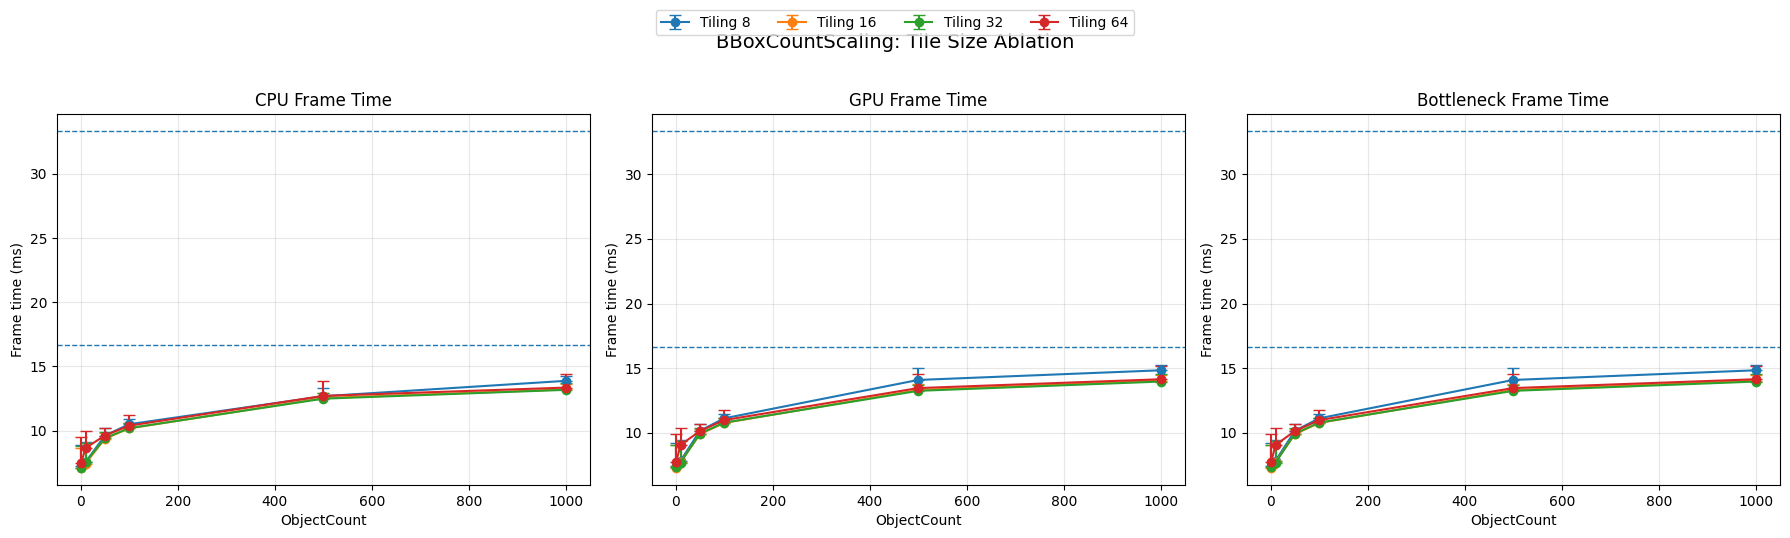

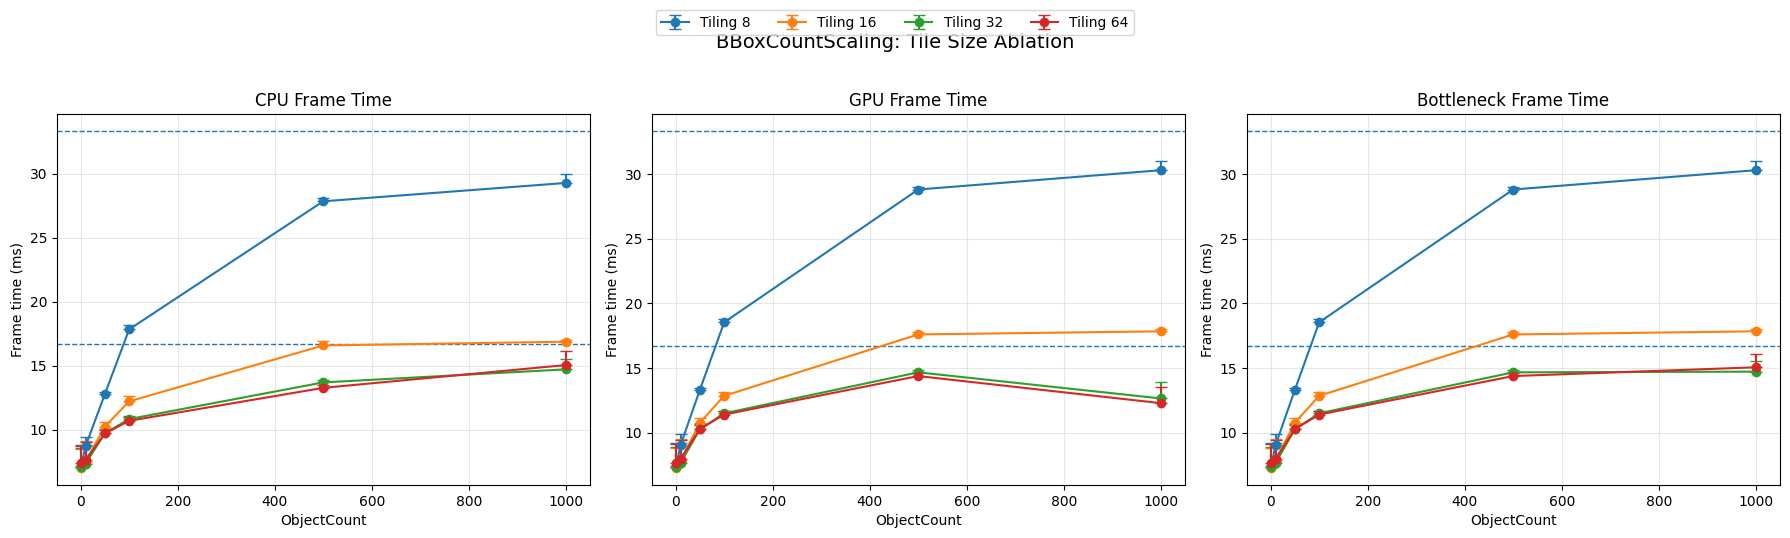

In [ ]:
plot_tiling_ablation_row(
    tiling_ablation_df,
    family="BBoxCountScaling",
    variable="ObjectCount",
    style_variant="SameStyle"
)

plot_tiling_ablation_row(
    tiling_ablation_df,
    family="BBoxCountScaling",
    variable="ObjectCount",
    style_variant="RandomSingleStyle"
)

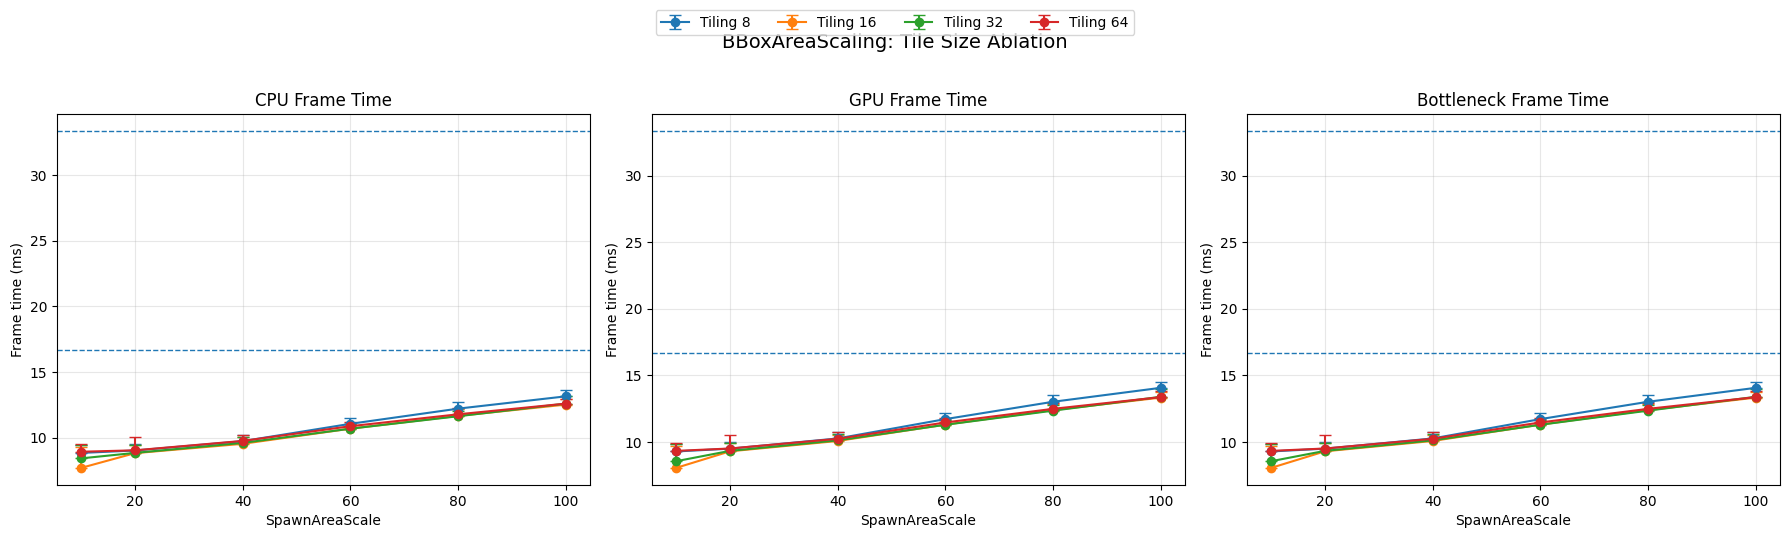

In [ ]:
plot_tiling_ablation_row(
    tiling_ablation_df,
    family="BBoxAreaScaling",
    variable="SpawnAreaScale",
    style_variant="SameStyle"
)

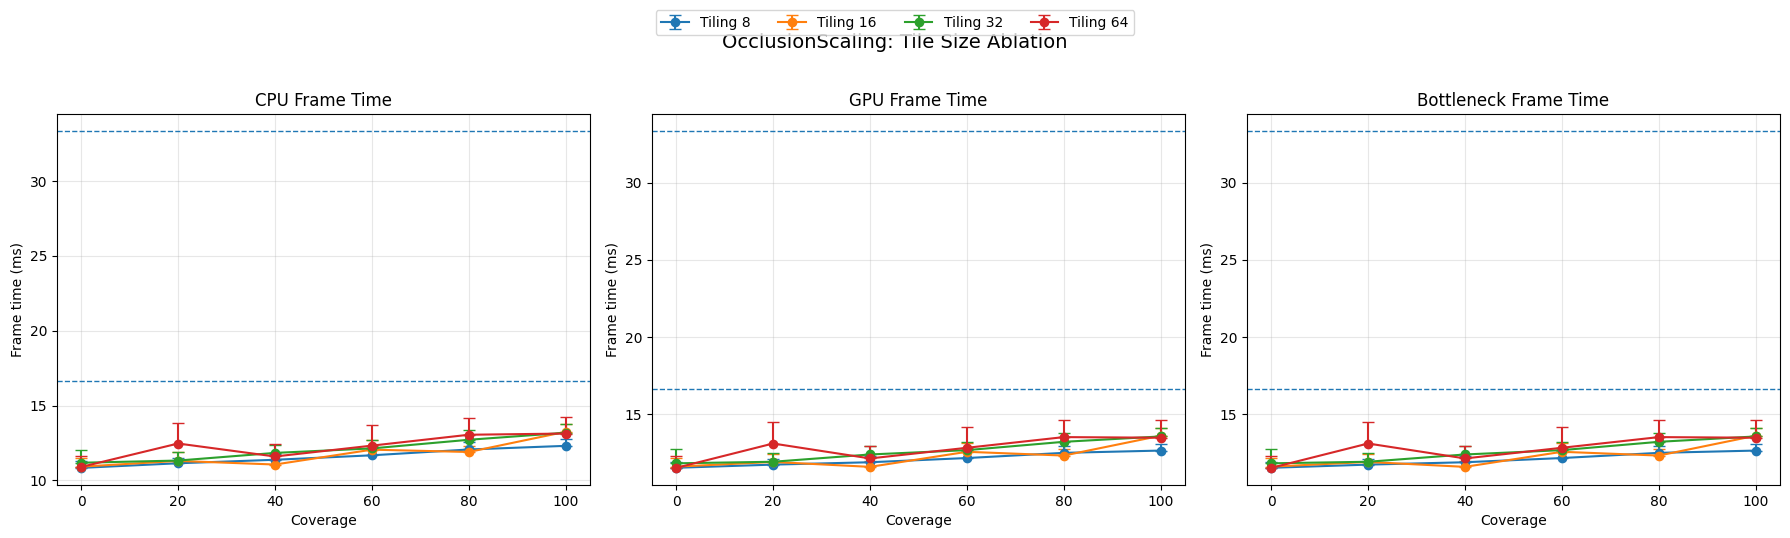

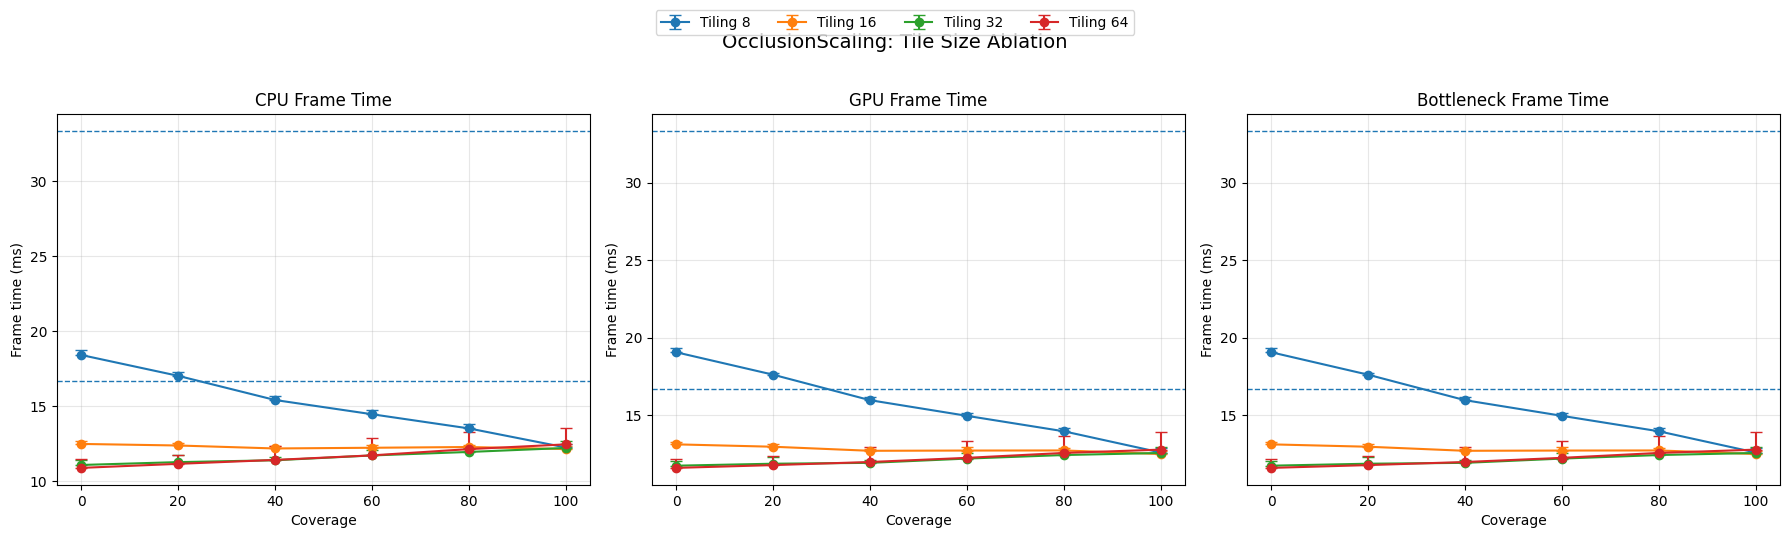

In [ ]:
plot_tiling_ablation_row(
    tiling_ablation_df,
    family="OcclusionScaling",
    variable="Coverage",
    style_variant="SameStyle",
)

plot_tiling_ablation_row(
    tiling_ablation_df,
    family="OcclusionScaling",
    variable="Coverage",
    style_variant="RandomSingleStyle",
)

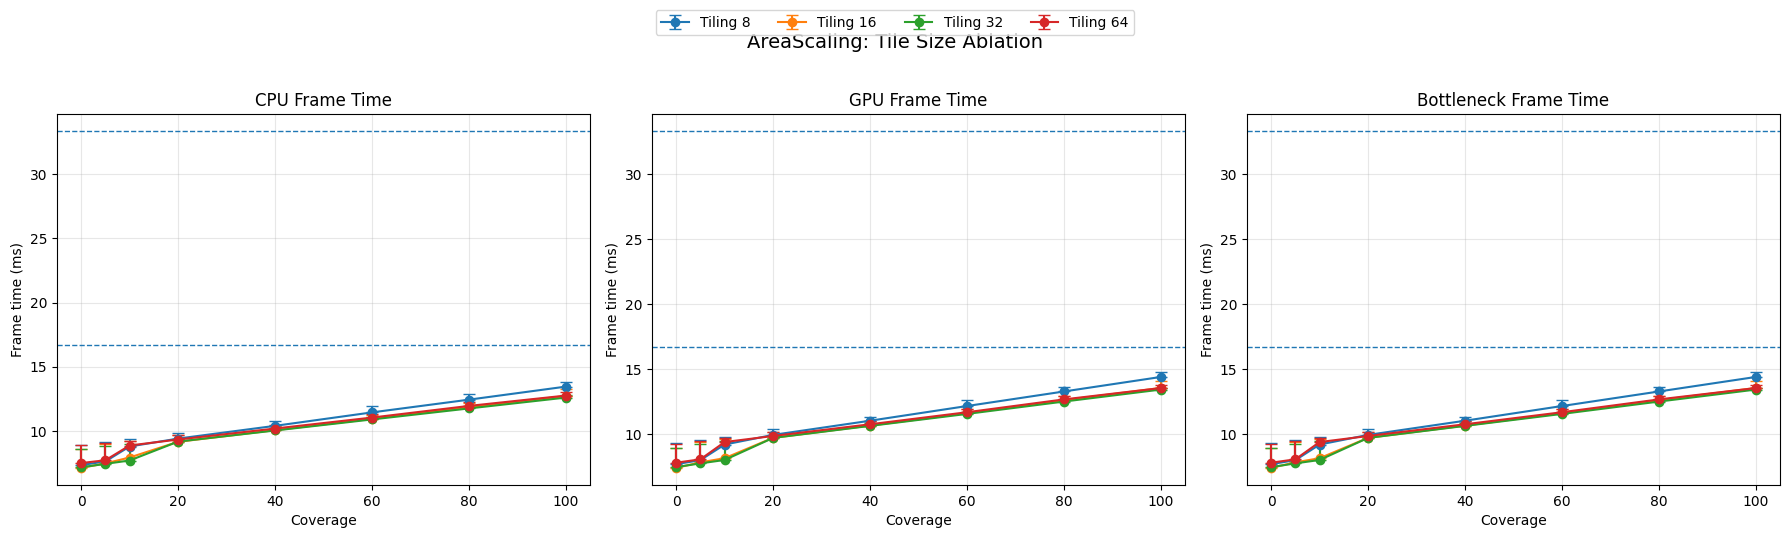

In [ ]:
plot_tiling_ablation_row(
    tiling_ablation_df,
    family="AreaScaling",
    variable="Coverage",
    style_variant="SameStyle",
)